In [1]:
import math
pi = math.pi
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
import random
random.seed(42)
from typing import List, Dict

In [2]:
class Const:
    rho_agua = 1.025    # ton/m³
    g = 9.81            # m/s²
    n_pontoons = 2
    n_colunas = 4
    gamma = 0.270

Curva de produção a ser atendida

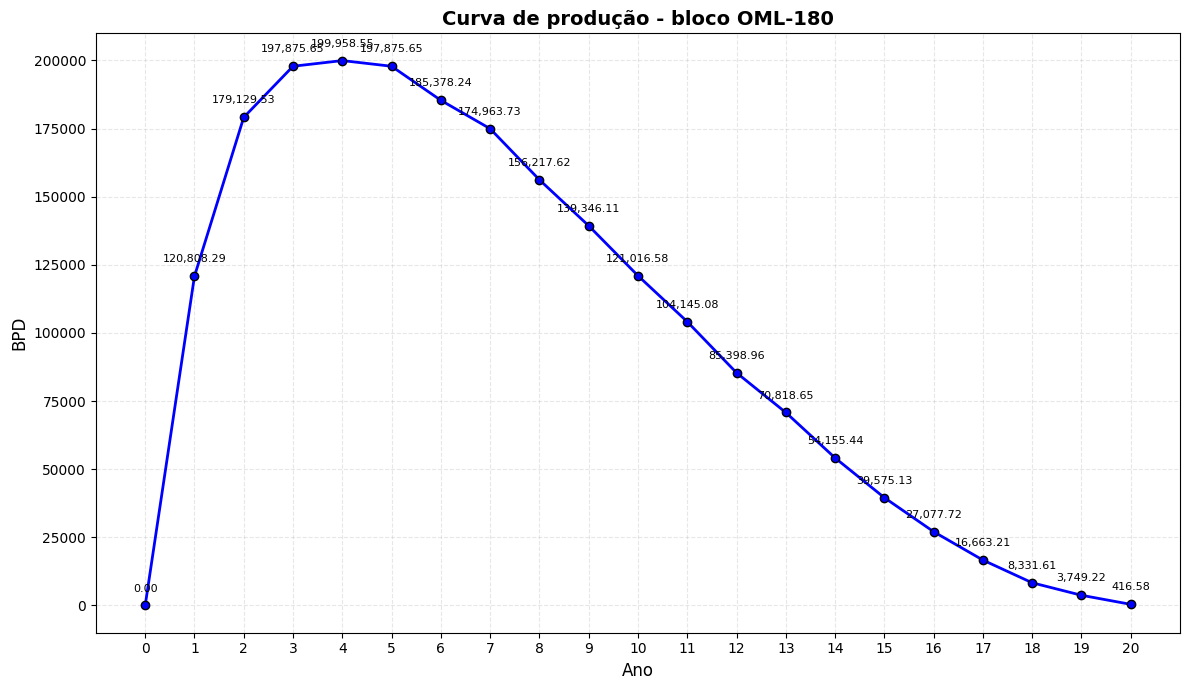

In [3]:
def curva_prod():
    # Dados fornecidos
    dados = [0.00, 120808.29, 179129.53, 197875.65, 199958.55, 
            197875.65, 185378.24, 174963.73, 156217.62, 139346.11,
            121016.58, 104145.08, 85398.96, 70818.65, 54155.44,
            39575.13, 27077.72, 16663.21, 8331.61, 3749.22, 416.58]

    # Criar array de índices (pontos no eixo x)
    x = np.arange(len(dados))

    # Configuração do gráfico
    plt.figure(figsize=(12, 7))

    # Plotar linha
    plt.plot(x, dados, marker='o', linestyle='-', linewidth=2, markersize=6,
            color='blue', markerfacecolor='blue', markeredgecolor='black')

    # Personalizar gráfico
    plt.title('Curva de produção - bloco OML-180', fontsize=14, fontweight='bold')
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('BPD', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(x)  # Mostrar todos os índices no eixo x

    # Adicionar valores nos pontos
    for i, valor in enumerate(dados):
        plt.annotate(f'{valor:,.2f}', (i, valor), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

curva_prod()

In [4]:
def hidrostat(lp: float, bp: float, hp: float, bc: float, hc: float, t: float, visual: int = 0):
    """
    Calcula parâmetros hidrostáticos de uma plataforma semi-submersivel com dois pontoons paralelos simétricos
    
    Esta função calcula o volume deslocado, centro de carena (KB), raio metacêntrico
    transversal (BM), altura metacêntrica (KM) e deslocamento em massa para uma
    embarcação composta por dois pontoons paralelos com colunas.

    Parâmetros
    ----------
    lp : float
        Comprimento dos pontoons (m).
    bp : float
        Largura (boca) dos pontoons (m).
    hp : float
        Altura dos pontoons (m).
    bc : float
        Largura das colunas (m).
    hc : float
        Altura das colunas (m).
    t : float
        Calado (m).
    visual : int, opcional
        Flag para exibição dos resultados (0 = não exibir, 1 = exibir).
        Valor padrão é 0.

    Retorna
    -------
    float
        Altura metacêntrica (KM) em metros.
                
    Referências
    -----------
    Teoria de estabilidade naval para embarcações com múltiplos cascos.
    """

    # --- Cálculo do volume deslocado ---
    # Soma do volume da porção prismática e do volume do casco
    V = (4 * (t - hp) * bc**2) + (2 * lp * hp * bp)

    # --- Cálculo da altura do centro de carena (KB) ---
    # Representa o centroide da área submersa
    numerador_KB = ((lp * bp * hp**2) / 2) + (t + hp) * (t - hp) * bc**2
    denominador_KB = (lp * hp * bp) + 2 * (t - hp) * bc**2
    KB = numerador_KB / denominador_KB

    # --- Cálculo do momento de inércia da carena (Ic) ---
    # Considera simetria e distribuição de volume
    Ic = (bc**4) / 12 + bc**2 * ((lp / 2) - (bp / 2))**2

    # --- Cálculo do raio metacêntrico transversal (BM) ---
    BM = 4 * Ic / V

    # --- Cálculo da altura metacêntrica (KM) ---
    KM = KB + BM

    # --- Cálculo do deslocamento com densidade da água (ρ = 1.025 ton/m³) ---
    D = V * Const.rho_agua


    if bool(visual):
        print("PARÂMETROS DE ENTRADA")
        print(f"  Comprimento dos pontoons (Lp): {lp:.2f} m")
        print(f"  Largura dos pontoons (Bp): {bp:.2f} m")
        print(f"  Altura dos pontoons (Hp): {hp:.2f} m")
        print(f"  Largura das colunas (Bc): {bc:.2f} m")
        print(f"  Altura das colunas (Hc): {hc:.2f} m")
        print(f"  Calado (t): {t:.2f} m")
        print()
        print("PARÂMETROS HIDROSTÁTICOS:")
        print(f"  Volume deslocado: {V:.2f} m³")
        print(f"  KB: {KB:.2f} m")
        print(f"  BM: {BM:.2f} m")
        print(f"  KM: {KM:.2f} m")
        print(f"  Deslocamento em massa: {D:.2f} t")
        print()

    return KM, D

In [5]:
def pesos(lp: float, bp: float, hp: float, bc: float, hc: float, t: float, boe: float = 1.2e5, visual: int = 0):
    """
    Calcula pesos e centros de gravidade de uma plataforma semi-submersível.
    
    Esta função calcula os pesos individuais dos componentes (topside, casco, lastro,
    risers, amarração) e seus respectivos centros de gravidade vertical (VCG), além
    de determinar parâmetros de estabilidade como altura metacêntrica (GM) e airgap.

    Parâmetros
    ----------
    lp : float
        Comprimento dos pontoons (m).
    bp : float
        Largura (boca) dos pontoons (m).
    hp : float
        Altura dos pontoons (m).
    bc : float
        Largura das colunas (m).
    hc : float
        Altura das colunas (m).
    t : float
        Calado (m).
    boe : float, opcional
        Capacidade de produção em Barrels of Oil Equivalent (BOE).
        Valor padrão é 200,000 BOE.
    visual : int, opcional
        Flag para exibição dos resultados (0 = não exibir, 1 = exibir).
        Valor padrão é 0.

    Retorna
    -------
    dict
        Dicionário contendo os seguintes parâmetros:
        - 'A_topside': Área do deck (m²)
        - 'P_casco': Peso do casco (ton)
        - 'restr_lastro': Restrição do lastro (booleano)
        - 'GM': Altura metacêntrica (m)
        - 'airgap': Distância entre nível da água e fundo do deck (m)
    
    Referências
    -----------
    Metodologia baseada em correlações empíricas para plataformas offshore.
    """

    # Obter parâmetros hidrostáticos
    KM, D = hidrostat(lp, bp, hp, bc, hc, t)     # Parâmetros hidrostáticos

    # --- Cálculo do topside (planta de produção) ---
    # Área do deck baseada em correlação empírica com capacidade
    A_topside = 42.246 * boe/1e3 + 4850.1    # Área do deck (m²)
    
    # Peso do topside - correlação típica de 83 kg por BOE de capacidade
    P_topside = boe * 83/1e3                 # Peso do topside (ton)
    
    # VCG do topside - assumido 10m acima do topo das colunas
    VCG_topside = hp + hc + 10               # VCG topside (m)


    # --- Cálculo da estrutura do casco ---
    # Peso dos pontoons (volume × quantidade × densidade)
    V_pontoons = lp * bp * hp * Const.n_pontoons            # Volume pontoons (m³)
    P_pontoons = V_pontoons * Const.gamma                   # Peso pontoons (ton)
    
    # Peso das colunas (volume × quantidade × densidade)  
    P_colunas = bc**2 * hc * Const.n_colunas * Const.gamma      # Peso colunas (ton)
    
    # Peso total do casco
    P_casco = P_pontoons + P_colunas                        # Peso casco (ton)
    
    # VCG do casco - média ponderada entre pontoons e colunas
    VCG_casco = (P_pontoons * (hp/2) + P_colunas * (hp + hc/2)) / P_casco  # VCG casco (m)


    # --- Cálculo de estruturas adicionais ---
    # Peso das estruturas do convés (35% do peso do topside)
    P_conves = P_topside * 0.35                             # Peso convés (ton)
    
    # Peso dos equipamentos operacionais (35% do peso do topside)  
    P_operacional = P_topside * 0.35                        # Peso operacional (ton)


    # --- Cálculo do peso total e VCG da plataforma ---
    # Pesos com mesmo VCG do topside
    P_topside_group = P_topside + P_conves + P_operacional
    
    
    # --- Cálculo de sistemas marítimos ---
    # Peso inicial da plataforma (sem risers e amarração)
    P_plataforma_inicial = P_topside_group + P_casco

    # Peso dos risers (4% do peso inicial da plataforma)
    P_riser = P_plataforma_inicial * 0.04                   # Peso risers (ton)
    
    # Peso do sistema de amarração (3% do peso inicial da plataforma)  
    P_amarracao = P_plataforma_inicial * 0.03               # Peso amarração (ton)
    
    # VCG dos risers e amarração - assumido no topo das colunas
    VCG_riser = hp + hc                                     # VCG risers/amarração (m)
    
    # Peso total da plataforma
    P_plataforma = P_plataforma_inicial + P_riser + P_amarracao  # Peso total (ton)


    # --- Cálculo do lastro (estrutura submersa) ---
    # Peso total do lastro
    P_lastro = D - P_plataforma                             # Peso lastro (ton)
    V_lastro = P_lastro / Const.rho_agua                    # Volume lastro (m³)
    restr_lastro = (0 <= V_lastro <= 0.9*V_pontoons)
    
    # VCG do lastro - assumido no centro dos pontoons
    VCG_lastro = hp/2                                       # VCG lastro (m)


    # Momentos individuais de cada componente
    momento_topside = P_topside_group * VCG_topside
    momento_casco = P_casco * VCG_casco
    momento_lastro = P_lastro * VCG_lastro
    momento_riser_group = (P_riser + P_amarracao) * VCG_riser
    
    # KG total - média ponderada de todos os momentos
    KG_plataforma = (momento_topside + momento_casco + momento_lastro + momento_riser_group) / P_plataforma  # KG total (m)


    # --- Cálculo de parâmetros de estabilidade e segurança ---
    # Altura metacêntrica (GM)
    GM = KM - KG_plataforma                                 # GM (m)
    
    # Airgap - distância entre nível d'água e fundo do deck
    airgap = hp + hc - t                                    # Airgap (m)


    # --- Retorno dos resultados ---
    if bool(visual):
        print("TOPSIDE:")
        print(f"  Peso inicial do topside: {P_topside:.1f} ton")
        print(f"  Peso conves: {P_conves:.1f} ton")
        print(f"  Peso operacional: {P_operacional:.1f} ton")
        print(f"  Peso total topside: {P_topside_group:.1f} ton")
        print(f"  VCG topside: {VCG_topside:.2f} m")
        print(f"  Área do topside/deck: {A_topside:.1f} m²")
        print()

        print("ESTRUTURA DO CASCO:")
        print(f"  Peso estrutura casco: {P_casco:.1f} ton")
        print(f"  VCG estrutura casco: {VCG_casco:.2f} m")
        print(f"  Peso riser: {P_riser:.1f} ton")
        print(f"  Peso amarração: {P_amarracao:.1f} ton")
        print()

        print("PESO PLATAFORMA:")
        print(f"  Peso total da plataforma: {P_plataforma:,.1f} ton")
        print(f"  KG plataforma: {KG_plataforma:.2f} m")
        print()

        print("PESO LASTRO:")
        print(f"  Deslocamento: {D:.1f} ton")
        print(f"  Peso lastro: {P_lastro:.1f} ton")
        print(f"  VCG lastro: {VCG_lastro:.2f} m")
        print()

        print("ESTABILIDADE E SEGURANÇA:")
        print(f"  Airgap: {airgap:.1f} m")
        print(f"  GM: {GM:.1f} m")
        print()
    

    return {
        'A_topside': A_topside,
        'P_casco': P_casco,
        'restr_lastro': restr_lastro,
        'GM': GM,
        'airgap': airgap
    }

In [6]:
def rao(lp: float, hp: float, bp: float, bc: float, hc: float, t: float, ger: int, zeta: float = 0.05, visual: int = 0):
    """
    Calcula os RAOs (Response Amplitude Operators) de uma plataforma semi-submersível.
    
    Esta função realiza análise hidrodinâmica completa, incluindo cálculo de forças
    hidrodinâmicas, segundo um modelo de forças de Froude-Krylov para partes descobertas
    e cobertas dos pontoons, determinação de massa adicional, frequência natural de heave,
    cálculo do RAO de heave, resposta ao espectro de onda JONSWAP e análise espectral.

    Considera ondas regulares com amplitude unitária (1m) para cálculo das forças. Utiliza 
    espectro JONSWAP para condições de mar com:
        * Tp = 14.7 s (período de pico)
        * Hs = 6.4 m (altura significativa)
        * gamma = 3.3 (fator de pico)

    Parâmetros
    ----------
    lp : float
        Comprimento dos pontoons (m).
    hp : float
        Altura dos pontoons (m).
    bp : float
        Largura (boca) dos pontoons (m).
    bc : float
        Largura (boca) das colunas (m).
    hc : float
        Altura das colunas (m).
    t : float
        Calado (m).
    zeta : float, opcional
        Fator de amortecimento estrutural (adimensional).
        Valor padrão é 0.05 (5%).
    visual : int, opcional
        Nível de visualização dos resultados:
        - 0: Apenas saída numérica
        - 1: Saída numérica completa
        - 2: Saída numérica + gráficos detalhados
        Valor padrão é 0.

    Retorna
    -------
    tuple
        (Tn, airgap_calc)
        Onde:
        - Tn: Período natural de heave (s)
        - airgap_calc: Soma da amplitude máxima da onda e do heave (m)

    Referências
    -----------
    - Teoria de Froude-Krylov para forças hidrodinâmicas
    - Modelo de massa adicional para seções transversais
    - Espectro JONSWAP para representação de estados de mar
    - Método espectral para análise de resposta em estruturas offshore
    """

    # Da geometria da plataforma
    dp = lp - bp                                                        # Distância entre os centros dos pontoons
    ld = lp - 2*bc                                                      # Comprimento dos pontoons descoberto de colunas
    D = ((4 * (t - hp) * bc**2) + (2 * lp * hp * bp)) * Const.rho_agua  # Deslocamento (ton)



    # --- Cálculo das forças hidrodinâmicas ---
    # Forças de Froude-Krylov
    def F_FKD(w):     # Aplicada as partes descobertas dos pontoons
        A = 1           # Amplitude da onda regular incidente unitário (m)
        forca = (4*ld*Const.rho_agua*Const.g**2*A * math.exp(-w**2*t/Const.g) *
                 (math.sin(w**2*bp/(2*Const.g))/w**2) * (1-math.exp(w**2*hp/Const.g)) *
                 math.cos(w**2*dp/(2*Const.g)))
        return forca

    def F_FKC(w):     # Aplicada as partes cobertas dos pontoons
        A = 1           # Amplitude da onda regular incidente unitário (m)
        forca = (8*bc*Const.rho_agua*Const.g**2*A * math.exp(-w**2*t/Const.g) *
                 (math.sin(w**2*bc/(2*Const.g))/w**2) * math.cos(w**2*dp/(2*Const.g)))
        return forca

    # Força da massa adicional
    def F_Ma(w):
        A = 1           # Amplitude da onda regular incidente unitário (m)
        Ma_2D = 1.51*Const.rho_agua*pi*(bp/2)**2
        Ma = 2 * Ma_2D * ld
        forca = ((-2*Ma_2D*A*ld*w**2) * math.exp(-w**2*(t-hp/2)/Const.g) *
                 math.cos(w**2*dp/(2*Const.g)))
        return forca, Ma

    # Força total de heave
    def F_total(w):
        return F_FKD(w) + F_FKC(w) + F_Ma(w)[0]

    # Outros parâmetros hidrodinâmicos da plataforma
    Ma = F_Ma(1e-4)[1]        # Massa adicional de heave
    wn = math.sqrt((4*Const.rho_agua*Const.g*bc**2)/(D + Ma))    # Frequência natural de heave
    Tn = 2*pi/wn                # Período natural de heave



    # --- Plotagem das forças hidrodinâmicas ---
    # Parâmetros para plotagem
    freq = np.linspace(1e-4, pi/2, 1000)
    F_FKD_vals = [F_FKD(w) for w in freq]
    F_FKC_vals = [F_FKC(w) for w in freq]
    F_Ma_vals = [F_Ma(w)[0] for w in freq]
    F_total_vals = [F_total(w) for w in freq]
    F_total_RAO = np.array(F_total_vals)

    

    # --- Cálculo do RAO de heave da plataforma e do espectro de JONSWAP ---
    def Z(w):
        f = F_total_RAO / (4*Const.rho_agua*Const.g*bc**2)
        Z = abs(f) / np.sqrt((1-(w/wn)**2)**2 + (2*zeta*(w/wn))**2)
        return Z
    RAO_heave = np.array(Z(freq))

    # Condições de mar de JONSWAP
    Tp = 14.7           # Periodo de pico, s
    wp = 2*pi/Tp        # Frequência de pico, rad/s
    Hs = 6.4            # Altura significativa, m
    gamma = 3.3         # Fator de pico
    alpha = 0.0624/(0.23 + 0.0336*gamma - 0.185/(1.9 + gamma))

    def jonswap(w):     # Espectro de JONSWAP
        tal = 0.07 if w <= wp else 0.09
        Sw = (alpha*Hs**2*w**(-5)/wp**(-4) * np.exp(-1.25*(w/wp)**-4) *
                    gamma**np.exp(-((w - wp)**2)/(2*(tal*wp)**2)))
        return Sw
    S = np.array([jonswap(w) for w in freq])



    # --- Cruzamento espectral para calculo de resposta significativa e airgap mínimo ---
    Sw_resp = S * RAO_heave**2          # Espectro de resposta em heave
    def m0(w):
        return np.trapezoid(Sw_resp, w)
    m0_val = m0(freq)                   # Momento zero do espectro de resposta

    Hs_resp = 4 * np.sqrt(m0_val)       # Altura significativa de heave

    # Amplitudes máximas esperadas
    A_max_onda = 1.86 * Hs / 2           # Amplitude máxima da onda
    A_max_heave = 1.86 * Hs_resp / 2     # Amplitude máxima do heave
    airgap_calc = A_max_onda + A_max_heave


    if bool(visual):
        print('PARÂMETROS HIDRODINÂMICOS:')
        print(f'  Massa adicional de heave: {Ma:.2f} ton')
        print(f'  Frequência natural de heave: {wn:.4f} rad/s')
        print(f'  Período natural de heave: {Tn:.2f} s')
        print(f'  Altura significativa de resposta em heave: {Hs_resp:.2f} m')
        print(f'  Amplitude significativa de resposta em heave: {Hs_resp/2:.2f} m')

        if visual > 1:
            
            if ger == 0:
                # Gráfico do espectro JONSWAP definido
                plt.figure(figsize=(9,6), dpi=150)
                plt.plot(freq, S, 'b')
                plt.title('Espectro de Energia - JONSWAP')
                plt.xlabel('Frequência (rad/s)')
                plt.ylabel('Espectro de Energia S(ω) (m²s)')
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

            # Grafico das forças hidrodinâmicas sob a plataforma
            plt.figure(figsize=(10,6), dpi=150)
            plt.plot(freq, F_FKD_vals, linewidth=1.5, c="y", label='Força Froude-Krylov - Partes Descobertas')
            plt.plot(freq, F_FKC_vals, linewidth=1.5, c="g", label='Força Froude-Krylov - Partes Cobertas')
            plt.plot(freq, F_Ma_vals, linewidth=1.5, c="m", label='Força de Massa Adicional')
            plt.plot(freq, F_total_vals, linewidth=3, c="r", label='Força Total de Heave')
            #plt.ylim(-1.1*max(F_total_vals), 1.1*max(F_total_vals))
            plt.title('Forças Hidrodinâmicas em Heave da Plataforma Semi-submersível')
            plt.legend()
            plt.xlabel('Frequência (rad/s)')
            plt.ylabel('Força (N)')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

            # Gráfico do RAO de heave da plataforma
            plt.figure(figsize=(10,6), dpi=150)
            plt.plot(freq, RAO_heave, 'c')
            plt.plot([wn, wn], [0, 2], 'r--')
            plt.ylim(0, 2)
            plt.title('RAO de heave da plataforma semi-submersível')
            plt.xlabel('Frequência (rad/s)')
            plt.ylabel('RAO (m/m)')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


    return Tn, airgap_calc, Hs_resp

In [7]:
def select_semisub(design: tuple, ger: int, imprimir: int = 0):
    """
    Executa análise completa de uma plataforma semi-submersível.
    
    Esta função coordena a execução das três principais análises da plataforma:
    hidrostática, de pesos e RAO (Response Amplitude Operators). Serve como ponto
    único de entrada para visualização dos dados de projeto de forma integrada.

    Parâmetros
    ----------
    design : tuple
        Tupla contendo as dimensões principais da plataforma na ordem:
        (Lp, Bp, Hp, Bc, Hc, t)
        
        Onde:
        - Lp: Comprimento dos pontoons (m)
        - Bp: Largura dos pontoons (m) 
        - Hp: Altura dos pontoons (m)
        - Bc: Largura das colunas (m)
        - Hc: Altura das colunas (m)
        - t: Calado (m)
        
    imprimir : int, opcional
        Controla o nível de detalhe da saída das funções chamadas:
        - 0: Não exibe saídas detalhadas
        - 1: Exibe saídas numéricas das análises
        - 2: Exibe saídas numéricas + gráficos (quando aplicável)
        Valor padrão é 0.

    Retorna
    -------
    None
        Esta função não retorna valores explicitamente, mas executa as análises
        e exibe os resultados conforme o parâmetro `imprimir`.
    """
    Lp, Bp, Hp, Bc, Hc, t = design

    _ = hidrostat(Lp, Bp, Hp, Bc, Hc, t, visual=imprimir)
    _ = pesos(Lp, Bp, Hp, Bc, Hc, t, visual=imprimir)
    _ = rao(Lp, Hp, Bp, Bc, Hc, t, ger, visual=imprimir)

In [8]:
def graf_peso(designs: List[Dict], ger: int):
    """
    Gera gráfico de dispersão do peso das plataformas vs período natural de heave.
    
    Esta função processa uma lista de designs de plataformas semi-submersíveis,
    calcula o peso do casco e o período natural de heave para cada um, e gera
    um gráfico de dispersão que relaciona essas duas importantes métricas.

    Parâmetros
    ----------
    designs : List[Dict]
        Lista de dicionários contendo os parâmetros de cada design de plataforma.
        Cada dicionário deve conter:
        - 'params': Tupla com as dimensões (Lp, Bp, Hp, Bc, Hc, t)
                
    ger : int
        Número da geração do processo de otimização, utilizado para título do gráfico.
        Ajuda a identificar a evolução dos designs ao longo das gerações.

    Retorna
    -------
    None
        A função exibe o gráfico gerado diretamente através do matplotlib.
    """
    pesos_list = []; y_list = []
    for platform in designs:
        lp, bp, hp, bc, hc, t = platform['params']
        resultados_pesos = pesos(lp, bp, hp, bc, hc, t)
        Tn, _, Hs_resp = rao(lp, hp, bp, bc, hc, t, ger)
        
        pesos_list.append(resultados_pesos['P_casco'])
        #y_list.append(Tn)
        y_list.append(Hs_resp)

    plt.figure(figsize=(9,6), dpi=150)
    plt.scatter(pesos_list, y_list, c='b')
    #plt.xlim(1e4, 12e4)
    #plt.ylim(18, 30)
    plt.title(f'{len(pesos_list)} soluções viáveis - geração {ger}')
    plt.xlabel('Peso da Plataforma (ton)')
    plt.ylabel('Período Natural de Heave (s)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
def encontrar_pareto_front(designs_validos: List[Dict]) -> List[Dict]:
    """
    Encontra a fronteira de Pareto (não-dominados) considerando:
    - Minimizar peso
    - Maximizar Tn
    """
    pareto_front = []
    
    for i, design in enumerate(designs_validos):
        dominado = False
        
        for j, outro in enumerate(designs_validos):
            if i == j:
                continue
                
            # Verificar se 'outro' domina 'design'
            if (outro['peso'] <= design['peso'] and outro['Tn'] >= design['Tn'] and
                (outro['peso'] < design['peso'] or outro['Tn'] > design['Tn'])):
                dominado = True
                break
        
        if not dominado:
            design['pareto'] = True
            pareto_front.append(design)
    
    return pareto_front


def selecionar_design_pareto(pareto_front: List[Dict], criterio: str = 'balanceado') -> Dict:
    """
    Seleciona design da fronteira de Pareto com diferentes critérios.
    
    Parâmetros:
    -----------
    pareto_front : List[Dict]
        Designs não-dominados
    criterio : str
        'leve' - menor peso na fronteira
        'rigido' - maior Tn na fronteira
        'balanceado' - distância mínima ao ideal (TOPSIS)
    """
    if not pareto_front:
        return None
    
    if criterio == 'leve':
        return min(pareto_front, key=lambda x: x['peso'])
    
    elif criterio == 'rigido':
        return max(pareto_front, key=lambda x: x['Tn'])
    
    elif criterio == 'balanceado':
        # Método TOPSIS
        pesos = [d['peso'] for d in pareto_front]
        Tns = [d['Tn'] for d in pareto_front]
        
        # Ponto ideal positivo (menor peso, maior Tn)
        ideal_pos = (min(pesos), max(Tns))
        # Ponto ideal negativo (maior peso, menor Tn)
        ideal_neg = (max(pesos), min(Tns))
        
        # Calcular distâncias
        scores = []
        for design in pareto_front:
            dist_pos = ((design['peso'] - ideal_pos[0])**2 + (design['Tn'] - ideal_pos[1])**2)**0.5
            dist_neg = ((design['peso'] - ideal_neg[0])**2 + (design['Tn'] - ideal_neg[1])**2)**0.5
            
            score = dist_neg / (dist_pos + dist_neg) if (dist_pos + dist_neg) > 0 else 0
            design['topsis_score'] = score
            scores.append(score)
        
        return pareto_front[scores.index(max(scores))]

In [10]:
def ga(lp: float, hp: float, bp: float, bc: float, hc: float, t: float, ger: int, n_simulacoes: int, retornar_pareto: bool = False) -> List[Dict]:
    """
    Gera e avalia designs de plataforma semi-submersível via amostragem aleatória.
    
    Esta função gera múltiplas configurações de plataforma através de perturbações
    aleatórias dos parâmetros de entrada e avalia se atendem aos critérios de
    projeto estabelecidos. Implementa um mecanismo de busca com amplitude
    decrescente ao longo das gerações.

    Parâmetros
    ----------
    lp : float
        Comprimento base dos pontoons (m).
    hp : float
        Altura base dos pontoons (m).
    bp : float
        Largura base dos pontoons (m).
    bc : float
        Largura base das colunas (m).
    hc : float
        Altura base das colunas (m).
    t : float
        Calado base (m).
    ger : int
        Número da geração atual. Controla a amplitude das perturbações:
        - Valor negativo: Amplitude fixa (0.05)
        - Valor positivo: Amplitude decrescente (1/(ger+1))
    n_simulacoes : int
        Número de designs aleatórios a serem gerados e avaliados.

    Retorna
    -------
    List[Dict]
        Lista de designs válidos ordenados por peso do casco (crescente).
        Cada dicionário contém:
        - 'id': Identificador sequencial do design
        - 'peso': Peso do casco (ton)
        - 'Tn': Período natural de heave (s)
        - 'params': Lista com parâmetros [lp, bp, hp, bc, hc, t]

    Notas
    -----
    Critérios de validação (todos devem ser atendidos):
    1. Estabilidade: GM entre 1 e 4 m
    2. Dinâmica: Período natural de heave > 20 s
    3. Lastro: Volume do lastro ≤ 90% do volume dos pontoons
    4. Airgap: Airgap estrutural > airgap mínimo calculado por RAO
    5. Geometria: t ≥ hp (calado maior que altura dos pontoons)
    6. Geometria: hp + hc ≥ t (colunas suficientemente altas)
    7. Deck: Área mínima do deck ≤ área real do deck

    O algoritmo:
    1. Define faixas de variação baseadas na geração atual
    2. Gera parâmetros aleatórios dentro dessas faixas
    3. Avalia cada design através das funções `pesos()` e `rao()`
    4. Armazena apenas os designs que passam em todos os critérios
    5. Ordena os designs válidos por peso do casco
    6. Gera gráfico de dispersão peso vs período natural
    7. Retorna lista ordenada de designs válidos
    """
    designs_validos = []

    if ger < 0:
        amplitude = 0.05
    else:
        amplitude = 1.0 / (ger + 1)

    lp_range = (lp*(1-amplitude), lp*(1+amplitude))
    bp_range = (bp*(1-amplitude), bp*(1+amplitude))
    hp_range = (hp*(1-amplitude), hp*(1+amplitude))
    hc_range = (hc*(1-amplitude), hc*(1+amplitude))
    t_range = (hp_range[1] + 1, hp_range[0] + hc_range[0] - 1)
    
    for i in range(n_simulacoes):
        # Gerar parâmetros aleatórios
        lp = random.uniform(*lp_range)
        bp = random.uniform(*bp_range)
        hp = random.uniform(*hp_range)
        bc = random.uniform(0.75*bp, bp)
        hc = random.uniform(*hc_range)
        t  = random.uniform(*t_range)

        
        # Executar e Extrair resultados de pesos e rao
        resultados_pesos = pesos(lp, bp, hp, bc, hc, t)
        #GM = resultados_pesos['GM']
        GM = 2
        restr_lastro = resultados_pesos['restr_lastro']
        airgap_calc = resultados_pesos['airgap']
        A_min = resultados_pesos['A_topside']
        Tn, airgap_min, Hs_resp = rao(lp, hp, bp, bc, hc, t, ger)

        
        # Avaliar critérios de projeto e restrições geométricas:
        if (not (1 <= GM <= 4) or not (Tn > 20) or not (restr_lastro) or 
            not (airgap_calc > airgap_min) or not (hp < t < hp + hc) or (A_min < lp**2)):
            continue
        
        # Se atender a todos os critérios, armazenar o design
        design = {'id': i, 'peso': resultados_pesos['P_casco'], 'Tn': Tn, 'Hs_resp': Hs_resp, 'params': [lp, bp, hp, bc, hc, t]}
        designs_validos.append(design)

    
    # Resumo final
    print(f"\nDesigns válidos encontrados pela geração {ger-1}: {len(designs_validos)}")
    graf_peso(designs_validos, ger-1)
    
    # return sorted(designs_validos, key=lambda x: x['peso'])

    designs_ordenados = sorted(designs_validos, key=lambda x: x['peso'])
    
    # Se solicitado, encontra e retorna a fronteira de Pareto
    if retornar_pareto and designs_ordenados:
        pareto_front = encontrar_pareto_front(designs_ordenados)
        
        # Opcional: adicionar informação de qual é o "melhor balanceado"
        if False:
            melhor_balanceado = selecionar_design_pareto(pareto_front, criterio='balanceado')
            print(f"\nDesign Pareto-ótimo selecionado (balanceado):")
            print(f"  ID: {melhor_balanceado['id']}, Peso: {melhor_balanceado['peso']:.2f} ton, Tn: {melhor_balanceado['Tn']:.2f} s")
        
        print(f"\nFronteira de Pareto: {len(pareto_front)} designs não-dominados")
        return pareto_front
    
    # Caso contrário, retorna todos ordenados por peso (comportamento original)
    return designs_ordenados

In [11]:
def main():
    """
    Implementa algoritmo de otimização para designs de plataformas semi-submersíveis.
    
    Esta função principal executa um processo iterativo de otimização que combina
    elementos de algoritmo genético e busca local para encontrar configurações
    ótimas de plataformas semi-submersíveis. O processo utiliza:
    1. Uma população inicial baseada em valores de referência
    2. Múltiplas gerações de evolução
    3. Seleção dos melhores designs de cada geração
    4. Atualização dos parâmetros via média dos designs selecionados

    Processo de otimização:
    ----------
    1. Geração 0:
       - Utiliza parâmetros iniciais de referência
       - Executa análise completa do design base
       
    2. Para cada geração subsequente (1 a N):
       - Gera múltiplos designs aleatórios ao redor do design atual
       - Seleciona os 10 melhores designs (menor peso do casco)
       - Atualiza o design atual como média dos parâmetros dos selecionados
       - Executa análise completa do novo design médio

    Parâmetros de configuração:
    ---------------------------
    As configurações abaixo podem ser alteradas conforme necessidade:
    - qtd_simul: 5000 designs gerados por geração
    - imprimir: Nível 2 (exibe gráficos e resultados detalhados)
    - geracoes: 5 iterações do processo evolutivo
    - Designs por geração: Top 10 designs selecionados

    Parâmetros iniciais de referência:
    ----------------------------------
    - Lp: 100 m (comprimento dos pontoons)
    - Bp: 15 m (largura dos pontoons)
    - Hp: 15 m (altura dos pontoons)
    - Bc: 15 m (largura das colunas)
    - Hc: 45 m (altura das colunas)
    - T: 30 m (calado)

    Critério de seleção:
    --------------------
    - Designs são ordenados por peso do casco (crescente)
    - Seleciona os N designs com menor peso que atendem aos critérios

    Notas
    -----
    - O processo converge gradualmente para designs mais leves e eficientes
    - Cada geração explora uma região menor ao redor do design atual
    - A média dos parâmetros suaviza a evolução e evita oscilações
    - O nível de detalhe da visualização (imprimir=2) permite acompanhar
      a evolução dos parâmetros hidrostáticos, de pesos e dinâmicos
    """

    # Parametros da otimização
    qtd_simul = 5000
    imprimir = 2
    designs_por_geracao = 20
    geracoes = 5
    
    # Parametros da população inicial
    Lp = 170; Bp = 40; Hp = 20; Bc = 23; Hc = 60; T = 35

    # Geração 0 - Design inicial de referência
    designAtual = [Lp, Bp, Hp, Bc, Hc, T]
    print(f"Geração 0")
    select_semisub(designAtual, 0, imprimir)

    
    for g in range(1,geracoes+1):
        designsNovos = ga(designAtual[0], designAtual[1], designAtual[2],
                                             designAtual[3], designAtual[4], designAtual[5], g, qtd_simul)
        selecao_natural = designsNovos[:designs_por_geracao]
        parametros = [item['params'] for item in selecao_natural]

        # Calcular a média de cada posição dos parâmetros
        media_parametros = []
        for i in range(6):  # para cada uma das 6 posições
            # Pegar o valor da posição i de todos os 5 itens
            valores_posicao_i = [params[i] for params in parametros]
            # Calcular a média
            media = sum(valores_posicao_i) / len(valores_posicao_i)
            media_parametros.append(media)
        designAtual = media_parametros

        print(f"Geração {g}")
        select_semisub(designAtual, g, imprimir)


    print('\n--- Indivíduos após otimização ---\n')

    print('Indivíduo com menor peso do casco:')
    select_semisub(designsNovos[0]['params'], -1, 2)

    print('Indivíduo com maior Tn:')
    melhor_Tn = max(designsNovos, key=lambda x: x['Tn'])
    select_semisub(melhor_Tn['params'], -1, 2)

Geração 0
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 170.00 m
  Largura dos pontoons (Bp): 40.00 m
  Altura dos pontoons (Hp): 20.00 m
  Largura das colunas (Bc): 23.00 m
  Altura das colunas (Hc): 60.00 m
  Calado (t): 35.00 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 303740.00 m³
  KB: 11.83 m
  BM: 29.74 m
  KM: 41.57 m
  Deslocamento em massa: 311333.50 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 90.00 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 107719.2 ton
  VCG estrutura casco: 22.73 m
  Peso riser: 4986.0 ton
  Peso amarração: 3739.5 ton

PESO PLATAFORMA:
  Peso total da plataforma: 133,376.8 ton
  KG plataforma: 48.36 m

PESO LASTRO:
  Deslocamento: 311333.5 ton
  Peso lastro: 177956.7 ton
  VCG lastro: 10.00 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 45.0 m
  GM: -6.8 m

PARÂMETROS HIDRODINÂMICOS:
  Massa adicional d

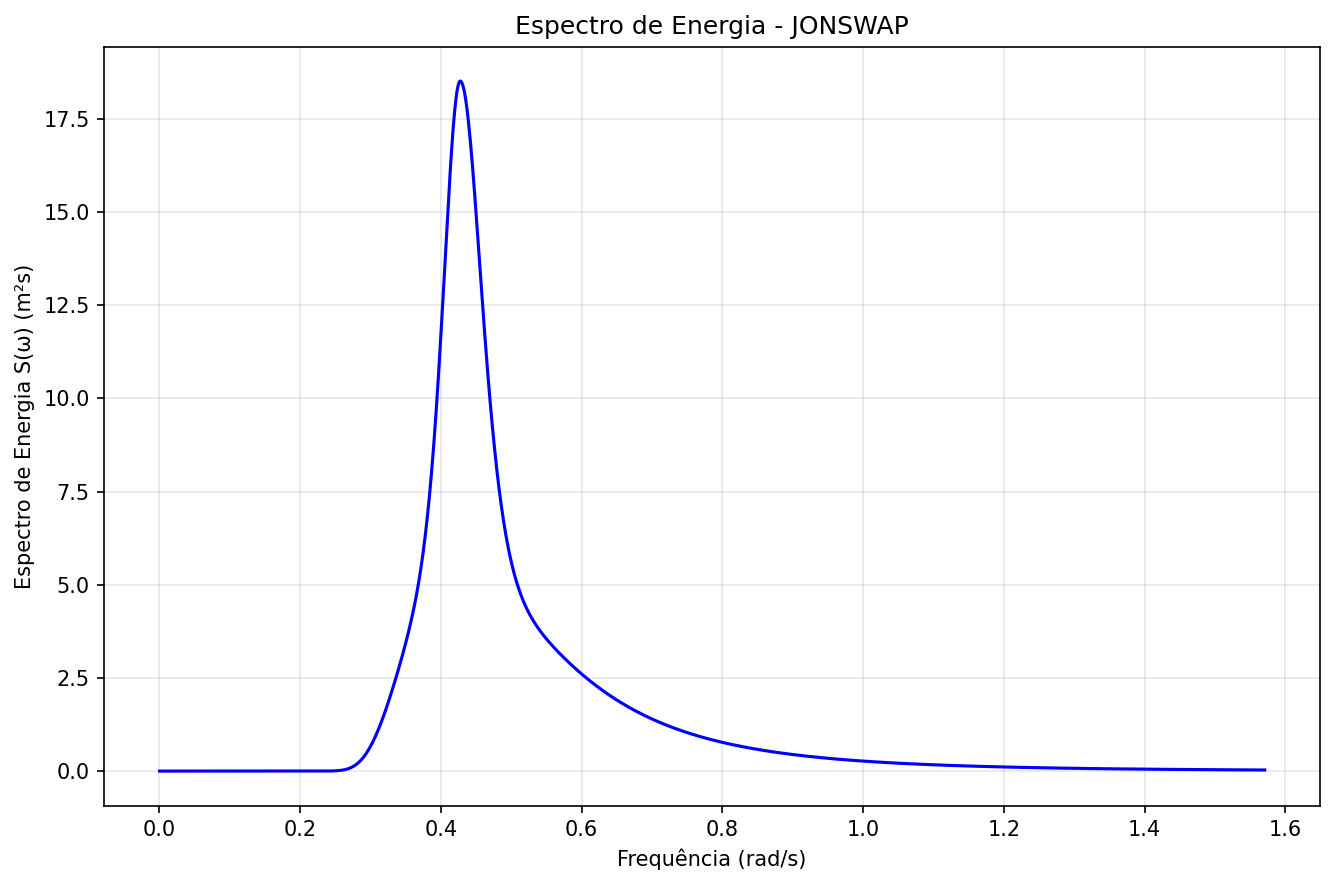

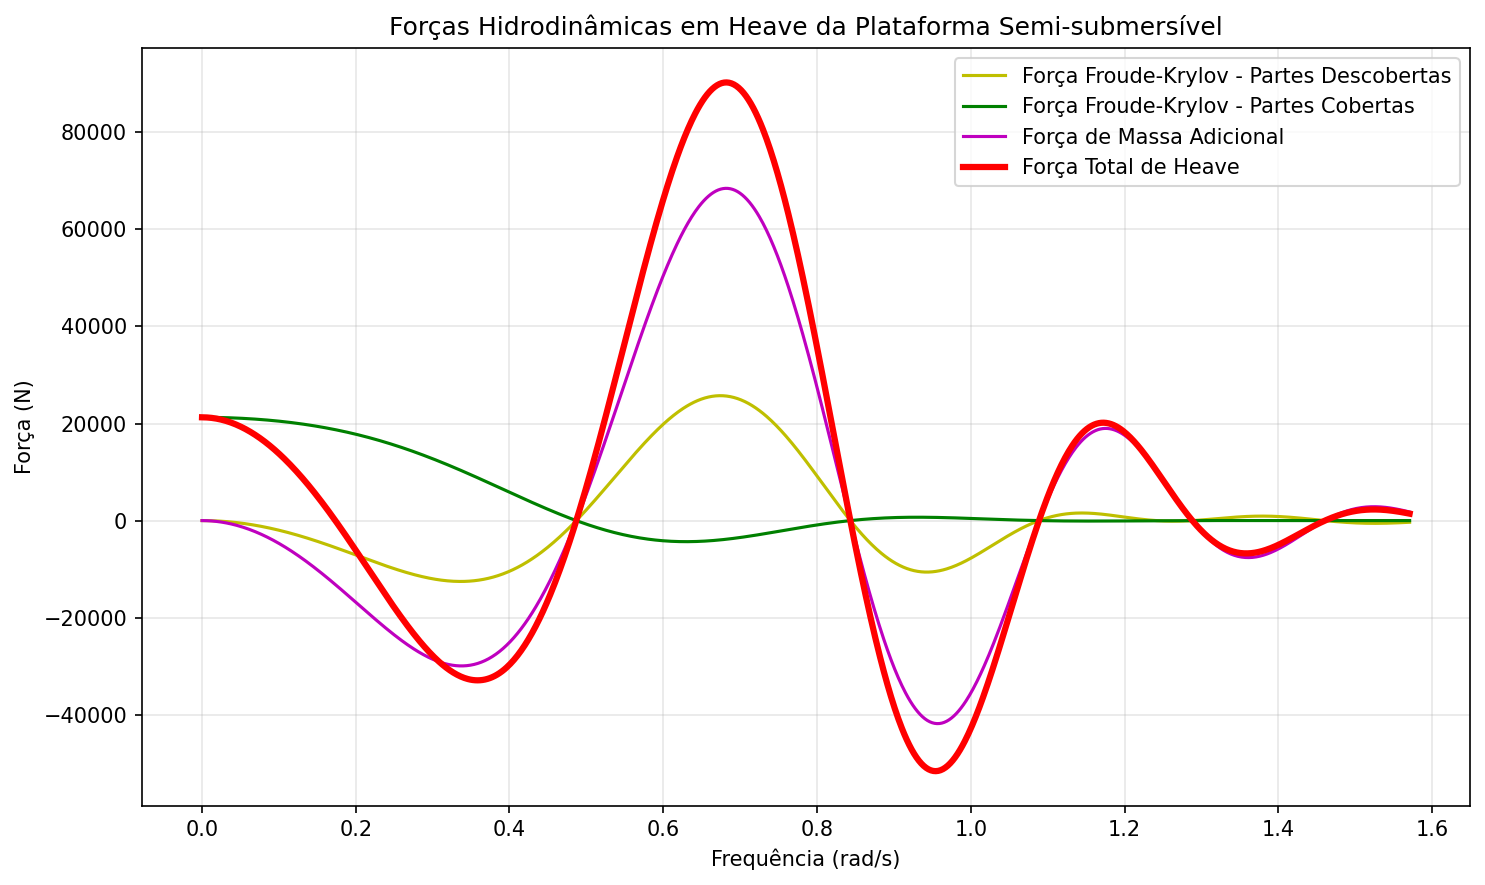

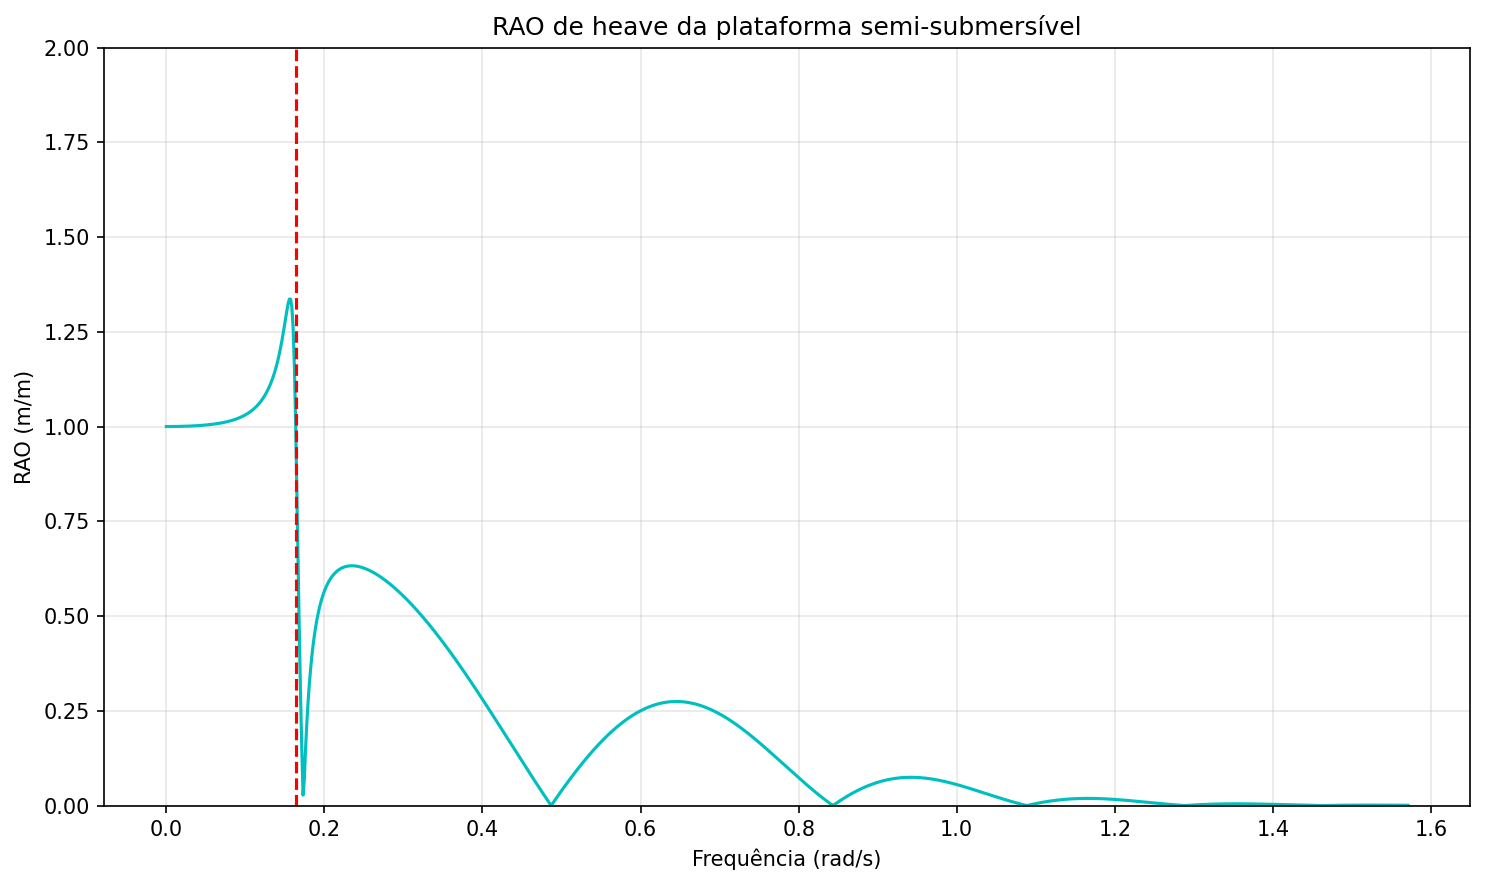


Designs válidos encontrados pela geração 0: 332


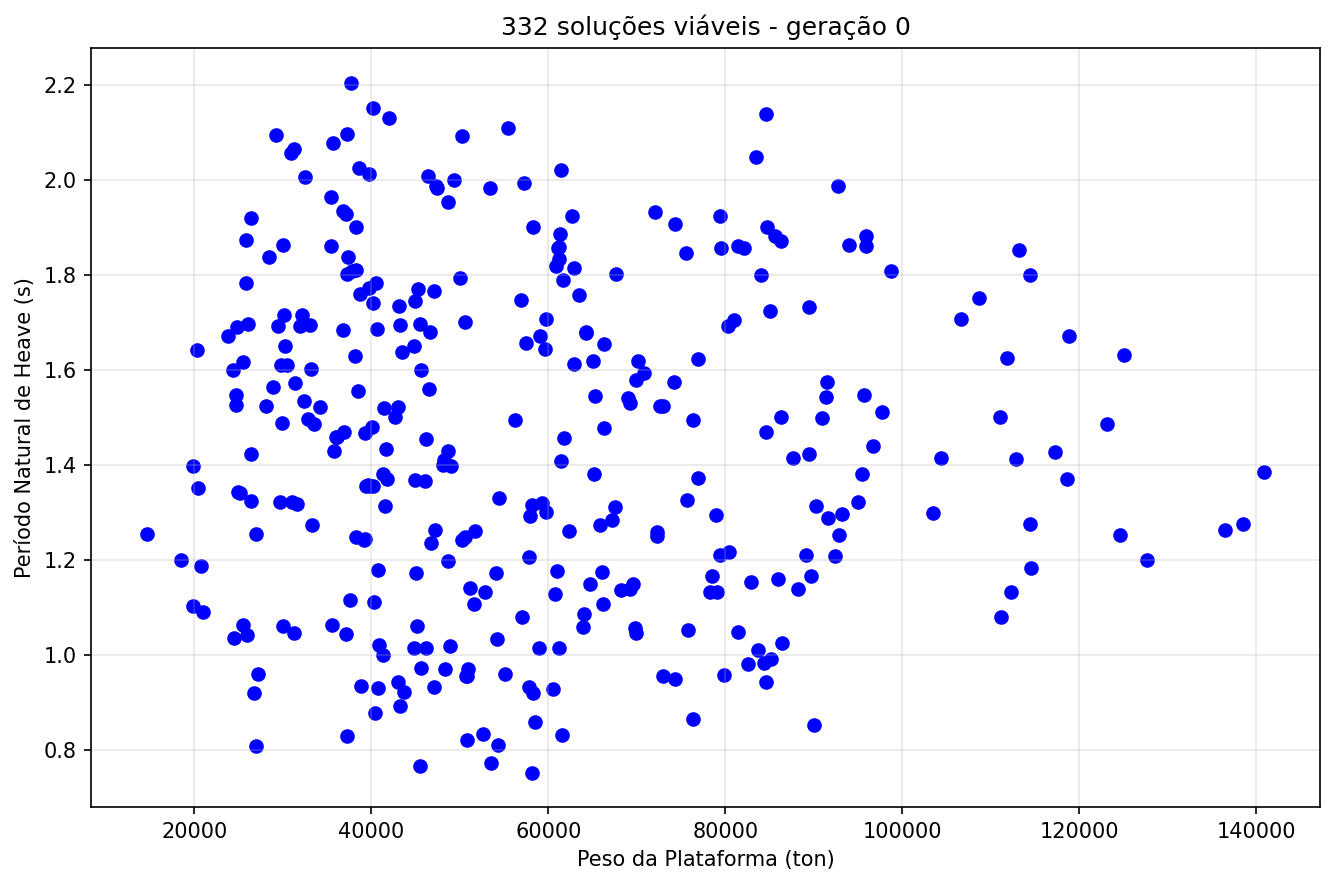

Geração 1
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 90.00 m
  Largura dos pontoons (Bp): 11.89 m
  Altura dos pontoons (Hp): 29.54 m
  Largura das colunas (Bc): 10.15 m
  Altura das colunas (Hc): 52.54 m
  Calado (t): 55.91 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 74076.65 m³
  KB: 18.87 m
  BM: 8.54 m
  KM: 27.41 m
  Deslocamento em massa: 75928.57 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 92.08 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 22913.6 ton
  VCG estrutura casco: 25.25 m
  Peso riser: 1593.8 ton
  Peso amarração: 1195.4 ton

PESO PLATAFORMA:
  Peso total da plataforma: 42,634.8 ton
  KG plataforma: 67.04 m

PESO LASTRO:
  Deslocamento: 75928.6 ton
  Peso lastro: 33293.8 ton
  VCG lastro: 14.77 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 26.2 m
  GM: -39.6 m

PARÂMETROS HIDRODINÂMICOS:
  Massa adicional de heave

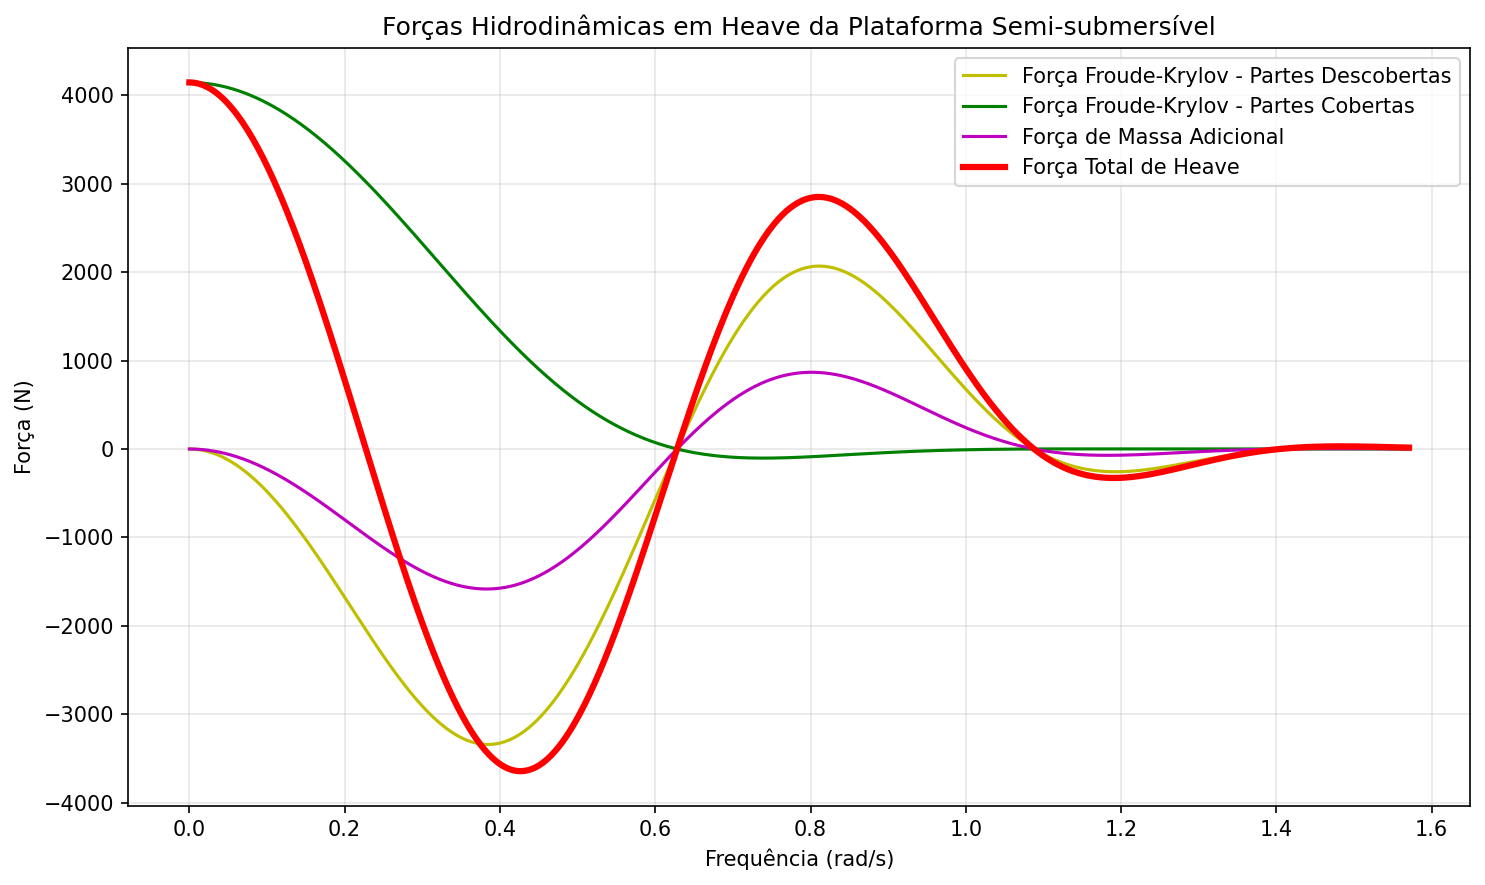

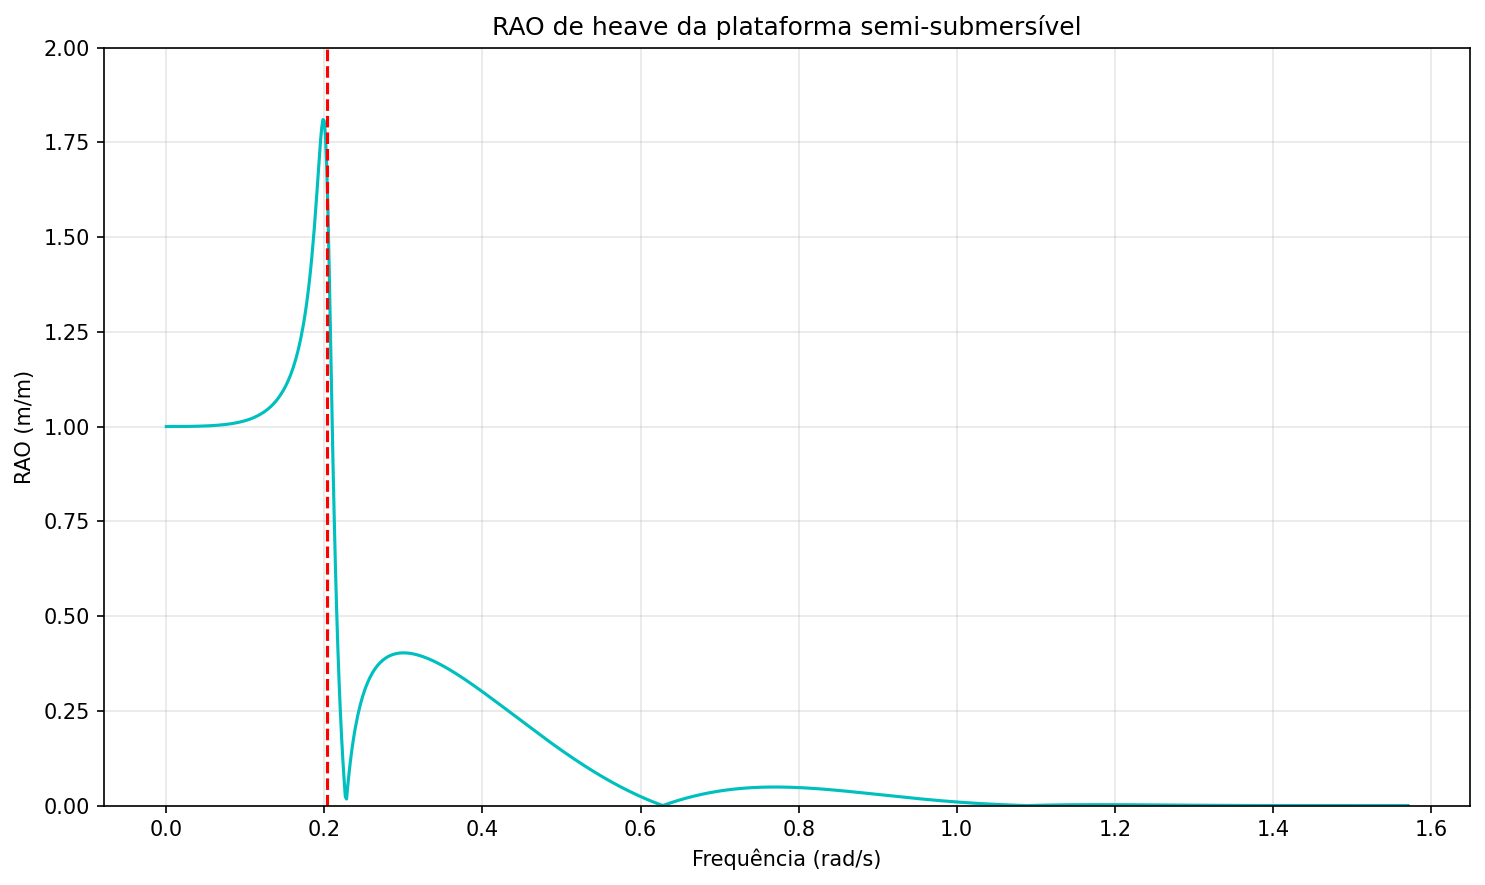


Designs válidos encontrados pela geração 1: 173


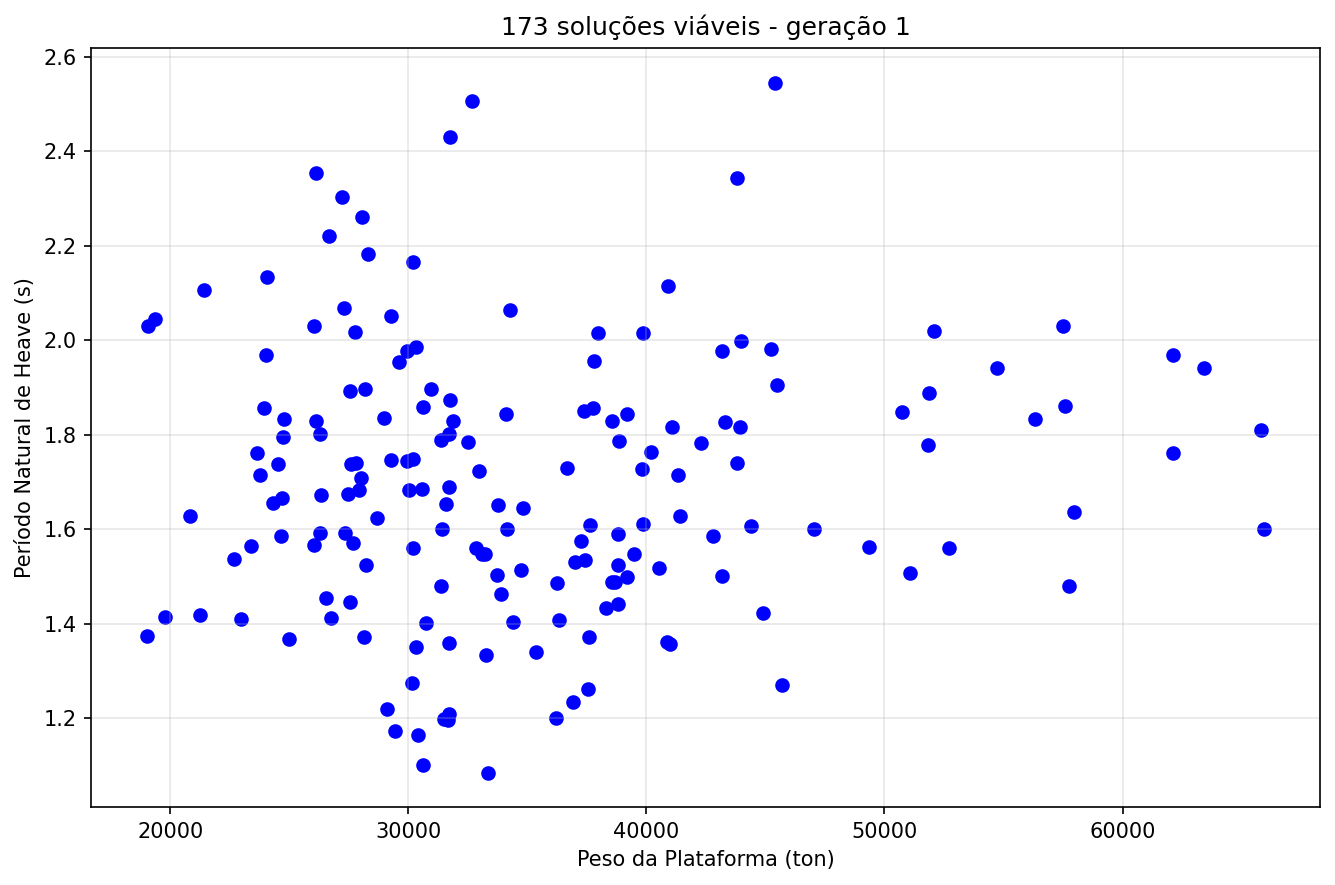

Geração 2
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 87.63 m
  Largura dos pontoons (Bp): 20.78 m
  Altura dos pontoons (Hp): 10.71 m
  Largura das colunas (Bc): 16.32 m
  Altura das colunas (Hc): 42.26 m
  Calado (t): 32.54 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 62249.61 m³
  KB: 11.43 m
  BM: 19.50 m
  KM: 30.93 m
  Deslocamento em massa: 63805.85 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 62.97 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 22682.8 ton
  VCG estrutura casco: 19.55 m
  Peso riser: 1584.6 ton
  Peso amarração: 1188.4 ton

PESO PLATAFORMA:
  Peso total da plataforma: 42,387.8 ton
  KG plataforma: 41.79 m

PESO LASTRO:
  Deslocamento: 63805.9 ton
  Peso lastro: 21418.0 ton
  VCG lastro: 5.35 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 20.4 m
  GM: -10.9 m

PARÂMETROS HIDRODINÂMICOS:
  Massa adicional de heave

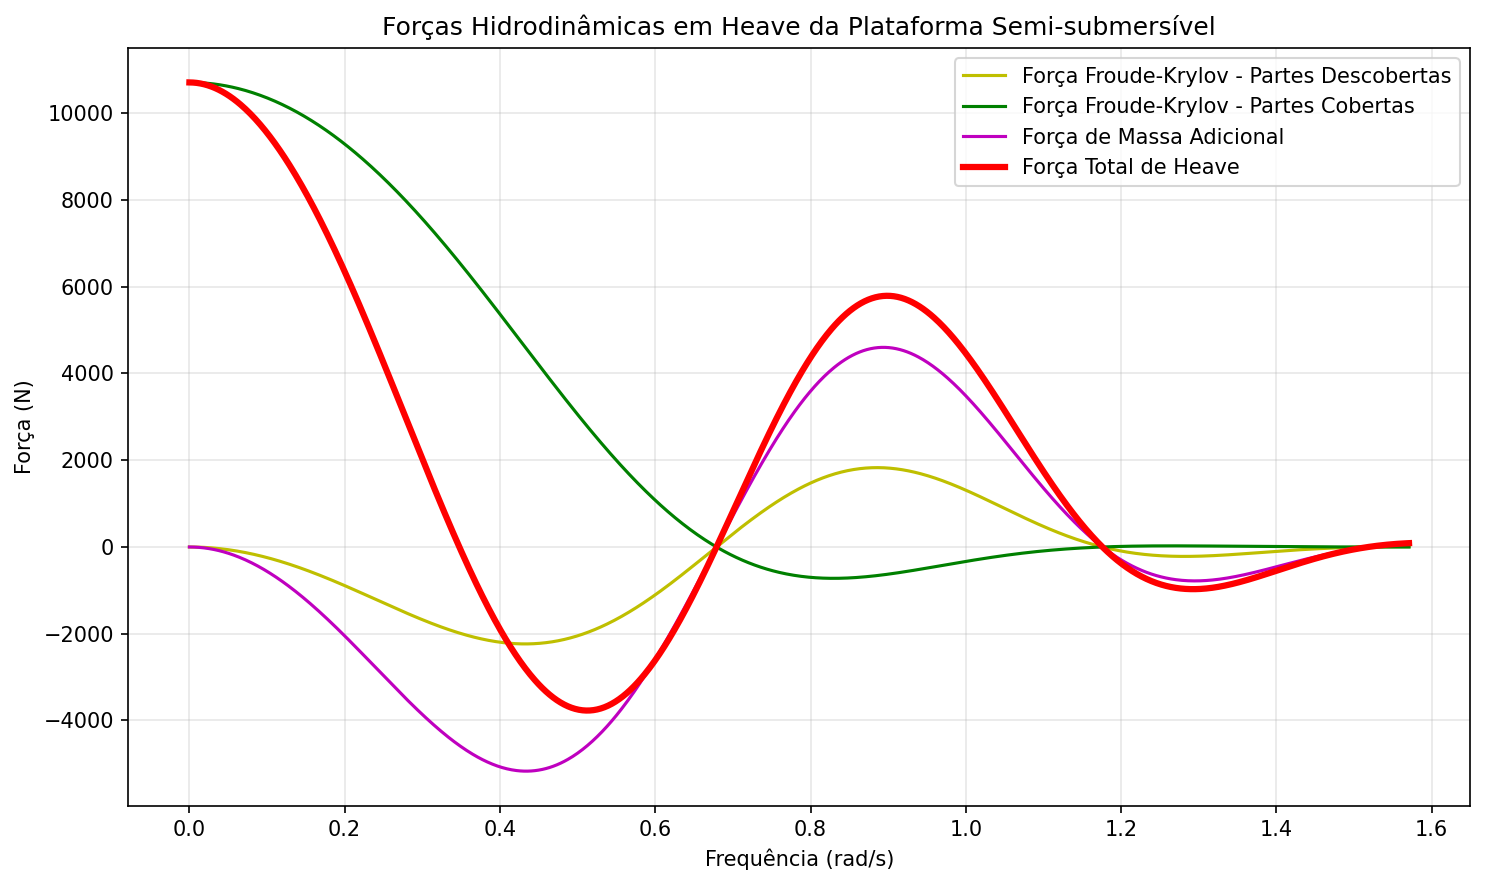

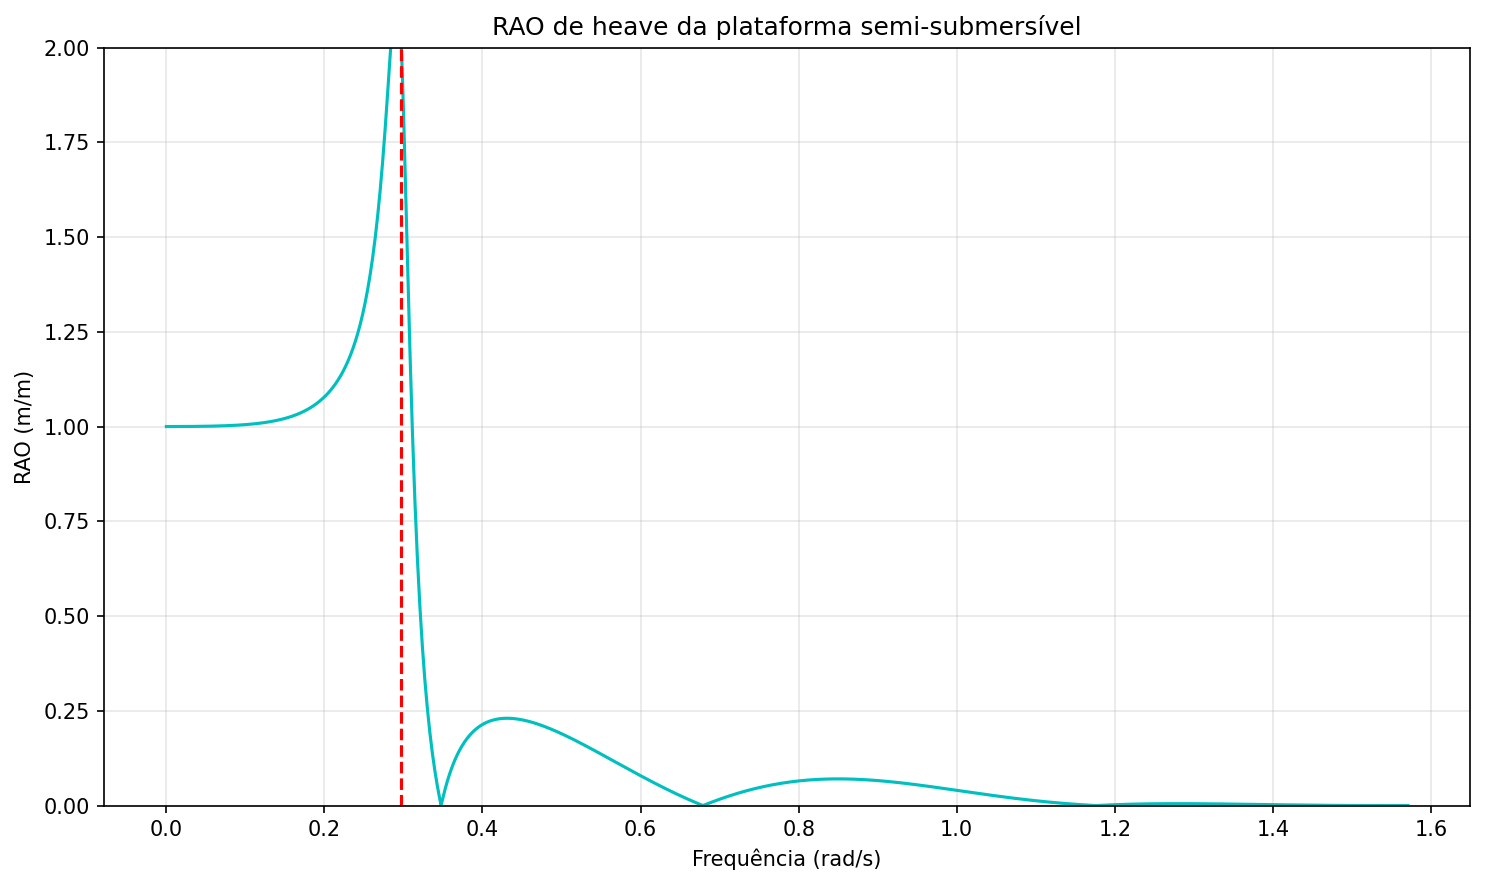


Designs válidos encontrados pela geração 2: 3660


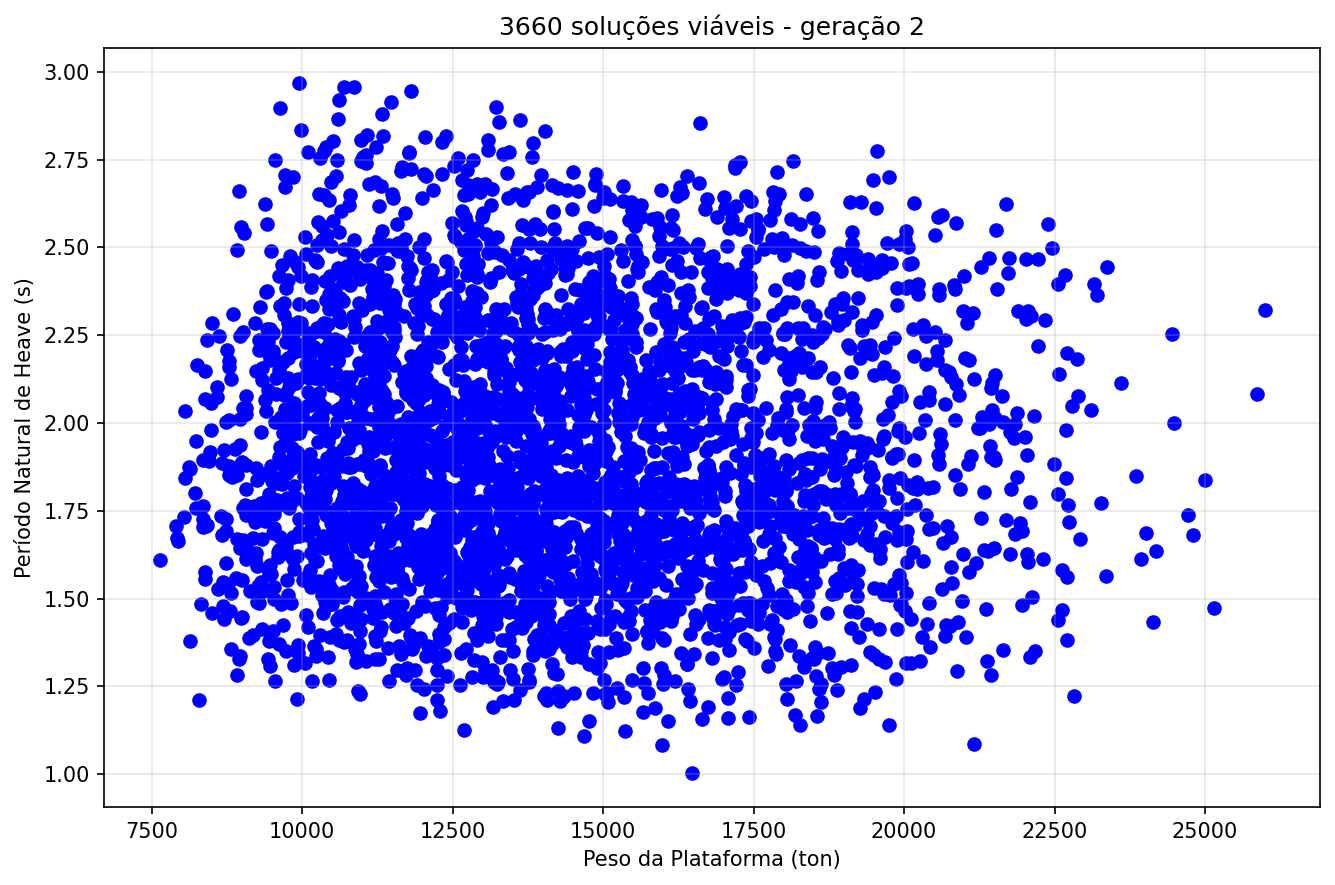

Geração 3
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 76.24 m
  Largura dos pontoons (Bp): 8.52 m
  Altura dos pontoons (Hp): 17.40 m
  Largura das colunas (Bc): 7.01 m
  Altura das colunas (Hc): 39.02 m
  Calado (t): 41.27 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 27296.54 m³
  KB: 12.25 m
  BM: 8.29 m
  KM: 20.54 m
  Deslocamento em massa: 27978.95 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 66.42 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 8174.2 ton
  VCG estrutura casco: 15.85 m
  Peso riser: 1004.2 ton
  Peso amarração: 753.2 ton

PESO PLATAFORMA:
  Peso total da plataforma: 26,863.6 ton
  KG plataforma: 50.74 m

PESO LASTRO:
  Deslocamento: 27979.0 ton
  Peso lastro: 1115.3 ton
  VCG lastro: 8.70 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 15.1 m
  GM: -30.2 m

PARÂMETROS HIDRODINÂMICOS:
  Massa adicional de heave: 1098

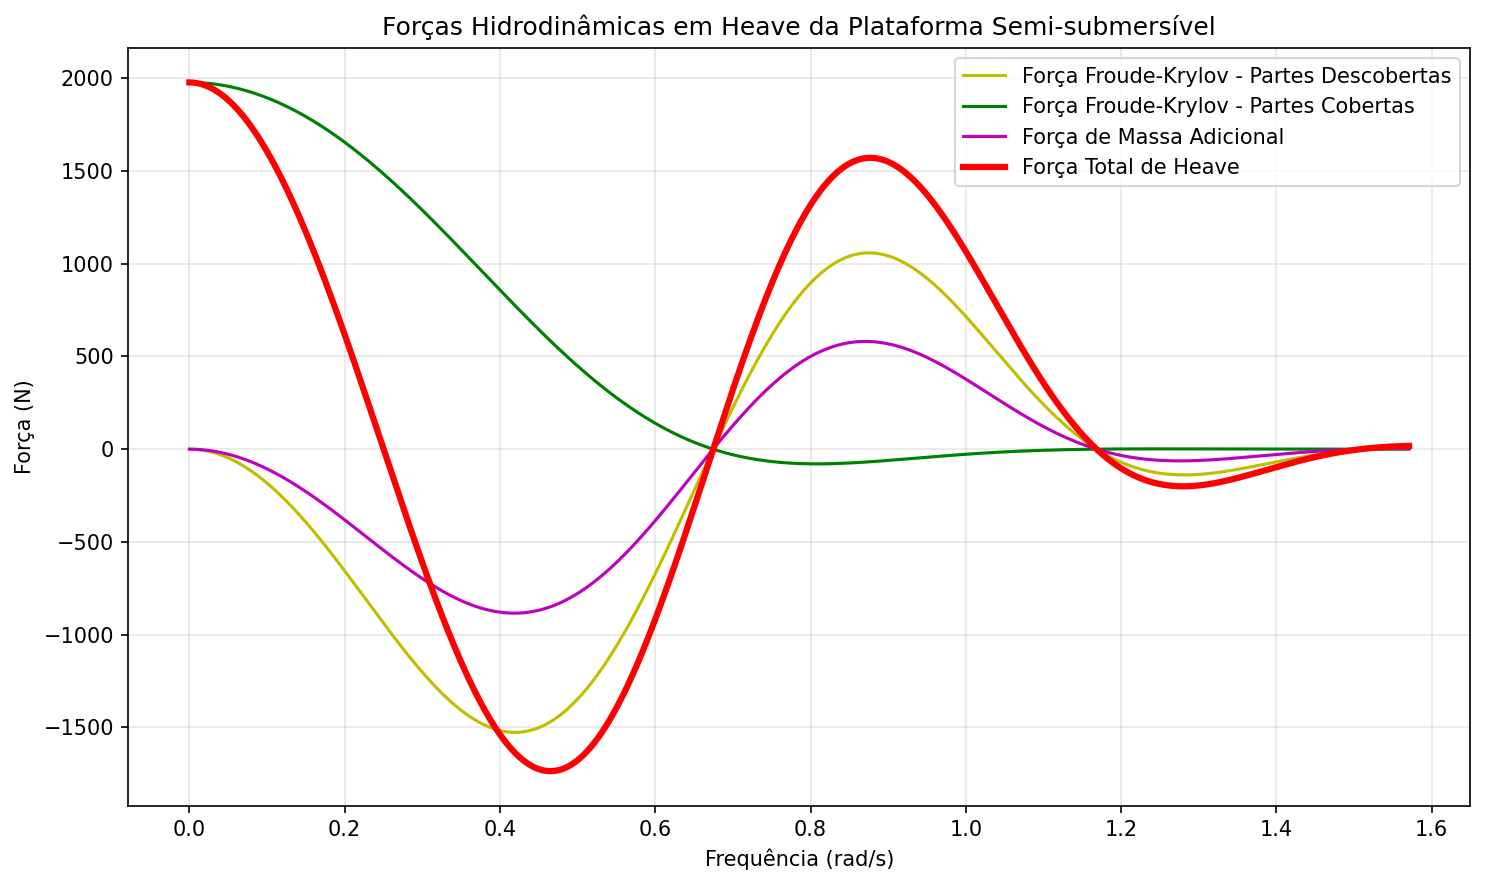

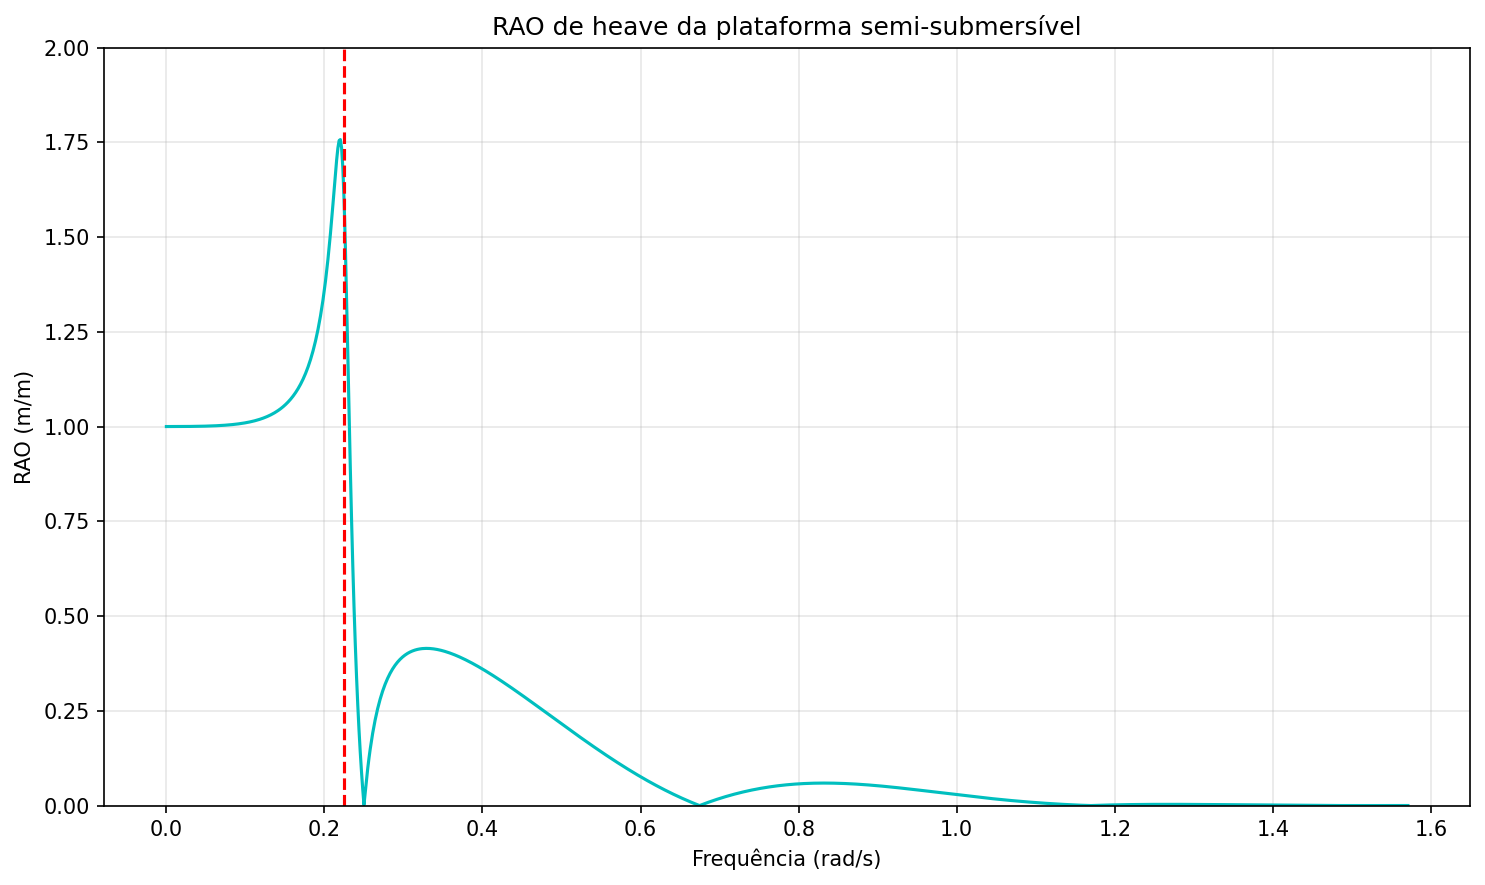


Designs válidos encontrados pela geração 3: 481


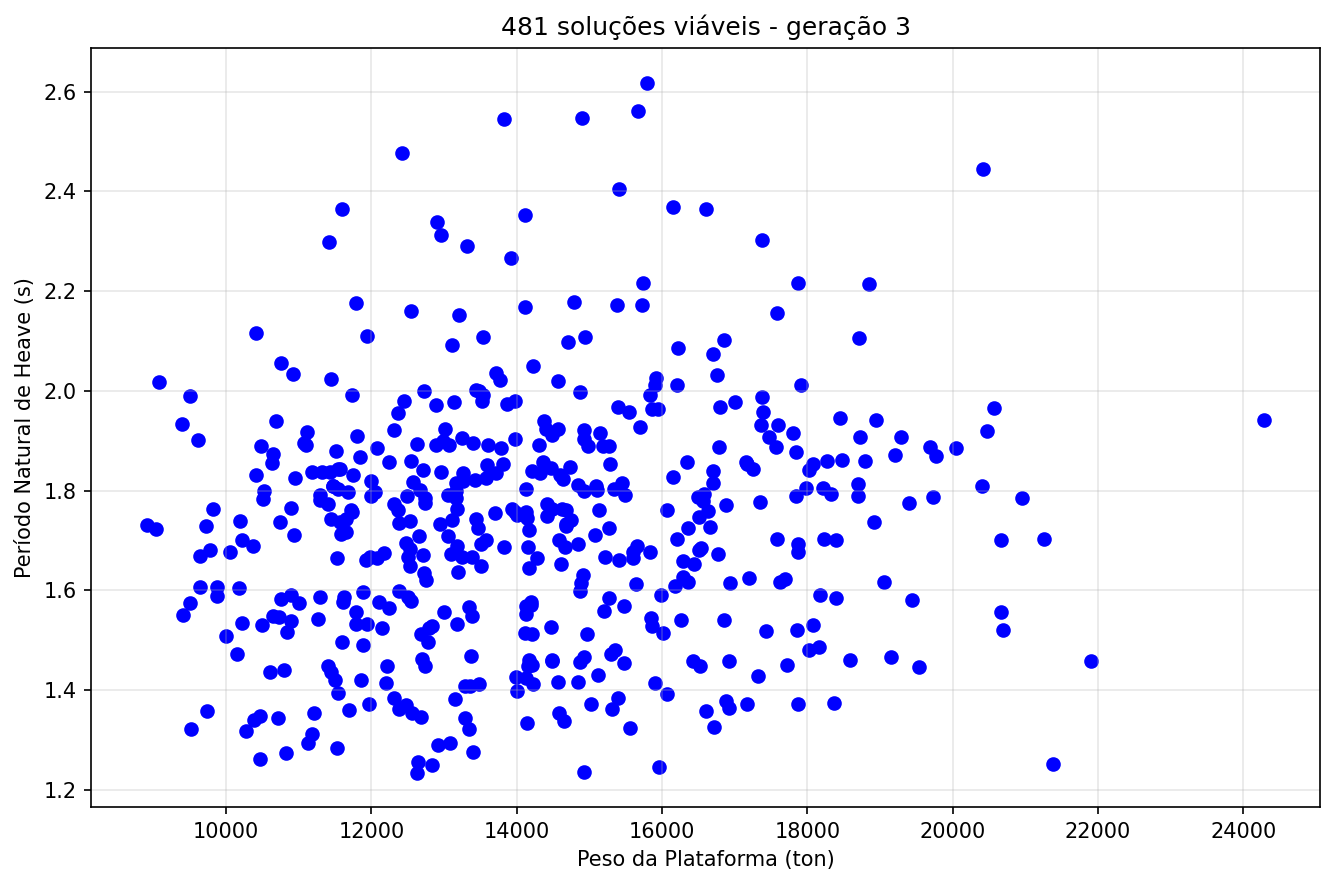

Geração 4
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 78.12 m
  Largura dos pontoons (Bp): 14.58 m
  Altura dos pontoons (Hp): 7.85 m
  Largura das colunas (Bc): 11.34 m
  Altura das colunas (Hc): 34.86 m
  Calado (t): 31.03 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 29793.51 m³
  KB: 10.13 m
  BM: 17.60 m
  KM: 27.73 m
  Deslocamento em massa: 30538.35 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 52.71 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 9664.8 ton
  VCG estrutura casco: 14.61 m
  Peso riser: 1063.9 ton
  Peso amarração: 797.9 ton

PESO PLATAFORMA:
  Peso total da plataforma: 28,458.6 ton
  KG plataforma: 39.40 m

PESO LASTRO:
  Deslocamento: 30538.3 ton
  Peso lastro: 2079.7 ton
  VCG lastro: 3.92 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 11.7 m
  GM: -11.7 m

PARÂMETROS HIDRODINÂMICOS:
  Massa adicional de heave: 28

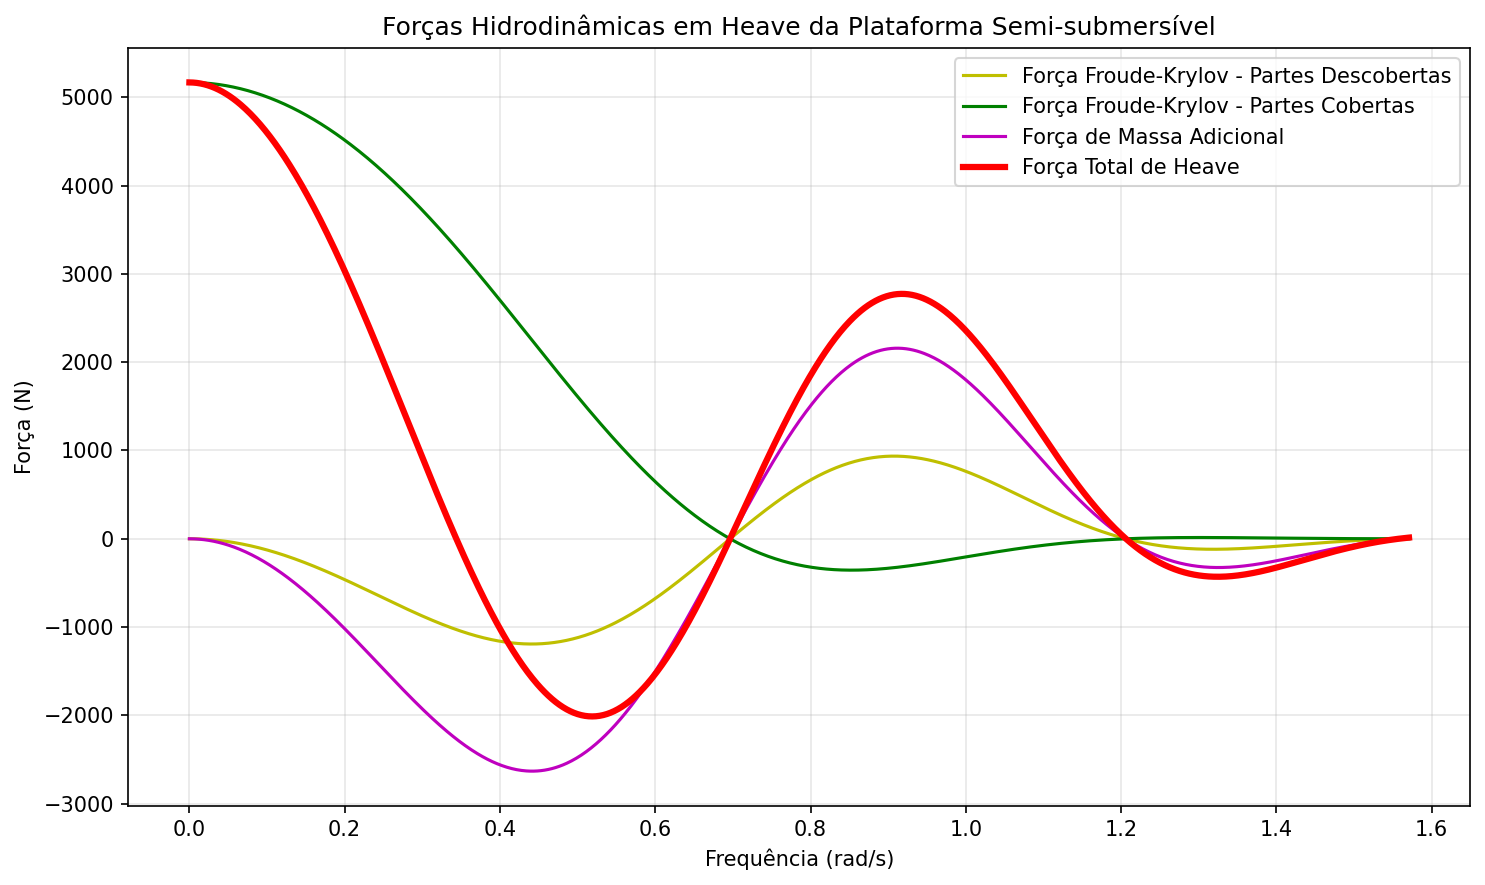

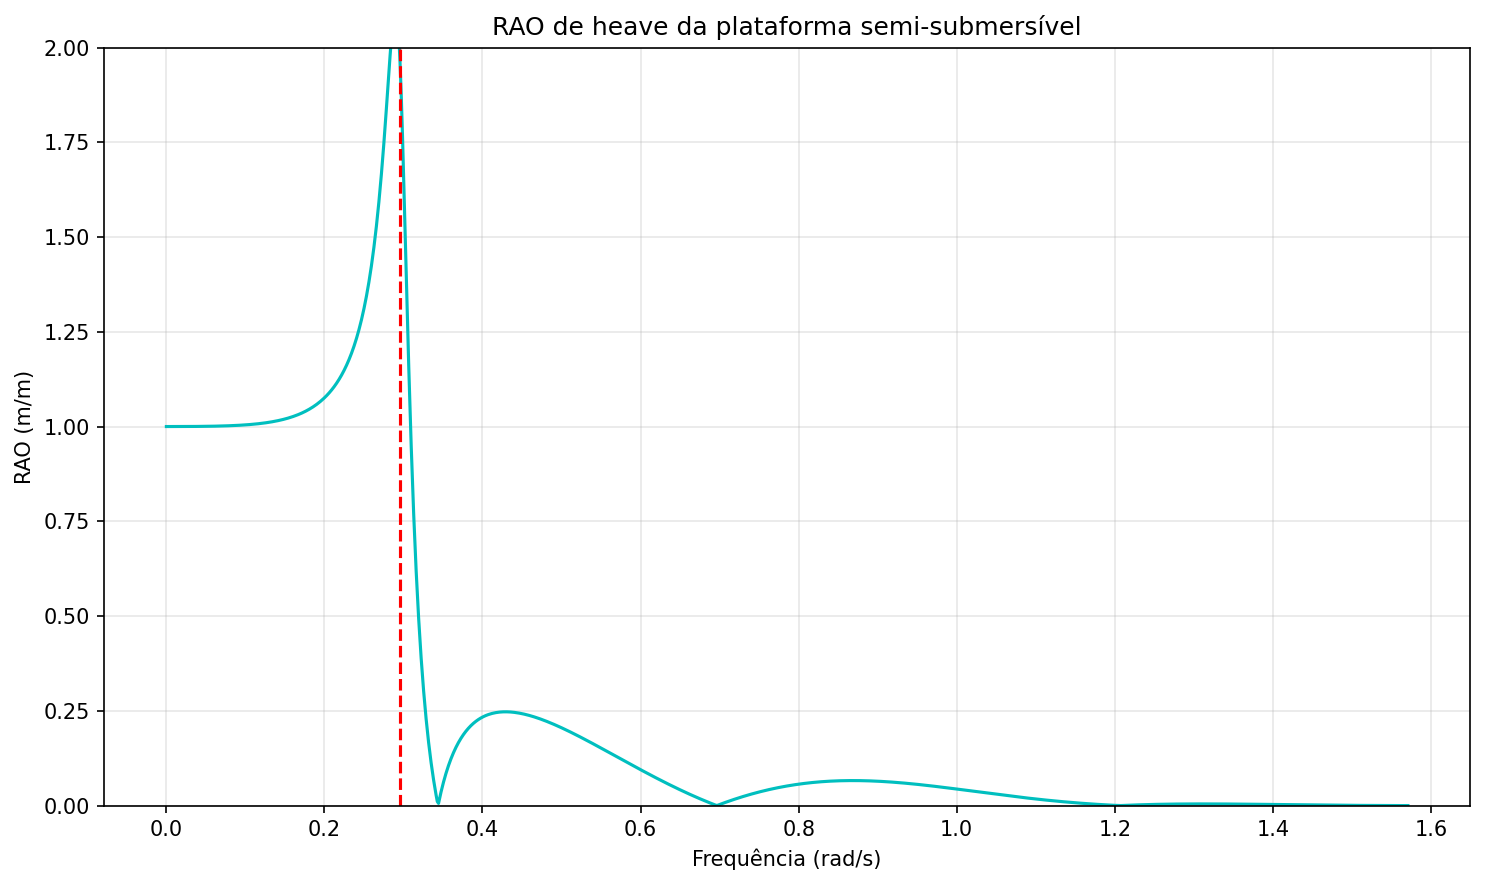


Designs válidos encontrados pela geração 4: 298


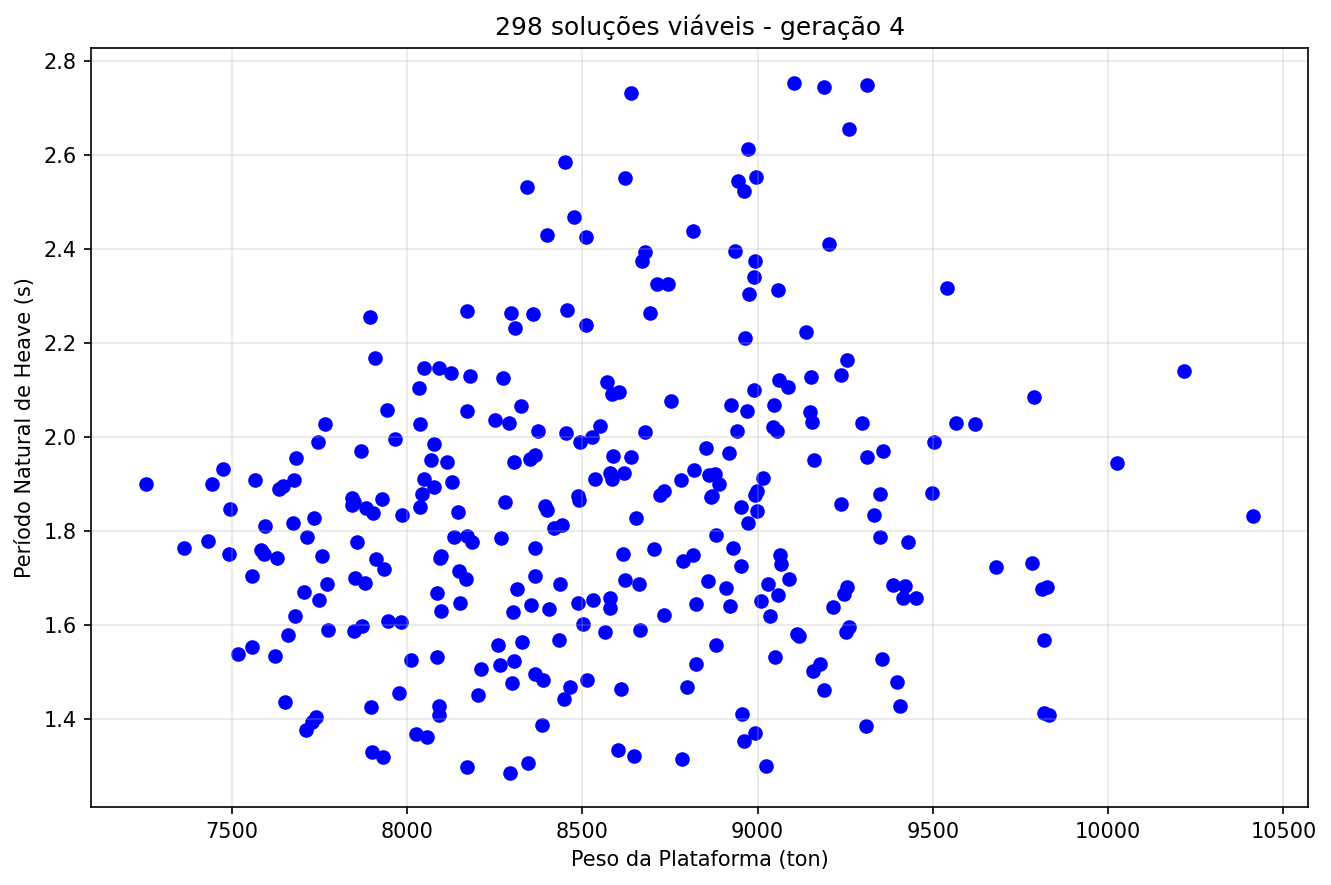

Geração 5
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 84.91 m
  Largura dos pontoons (Bp): 8.31 m
  Altura dos pontoons (Hp): 15.22 m
  Largura das colunas (Bc): 7.11 m
  Altura das colunas (Hc): 32.06 m
  Calado (t): 37.48 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 25984.90 m³
  KB: 10.85 m
  BM: 11.43 m
  KM: 22.28 m
  Deslocamento em massa: 26634.52 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 57.28 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 7549.9 ton
  VCG estrutura casco: 13.08 m
  Peso riser: 979.3 ton
  Peso amarração: 734.5 ton

PESO PLATAFORMA:
  Peso total da plataforma: 26,195.6 ton
  KG plataforma: 44.01 m

PESO LASTRO:
  Deslocamento: 26634.5 ton
  Peso lastro: 438.9 ton
  VCG lastro: 7.61 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 9.8 m
  GM: -21.7 m

PARÂMETROS HIDRODINÂMICOS:
  Massa adicional de heave: 11878.

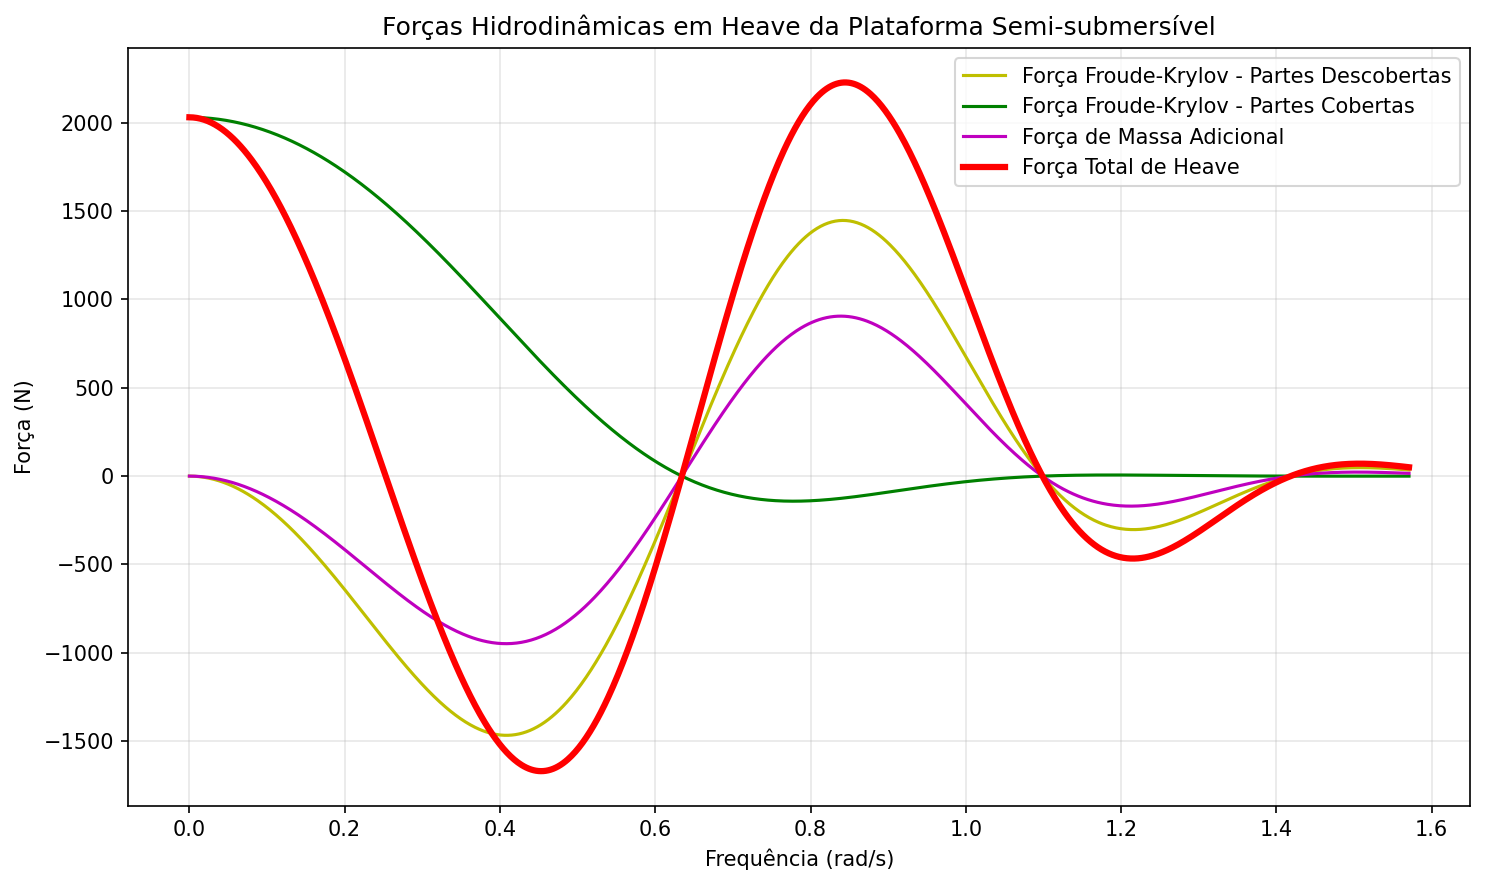

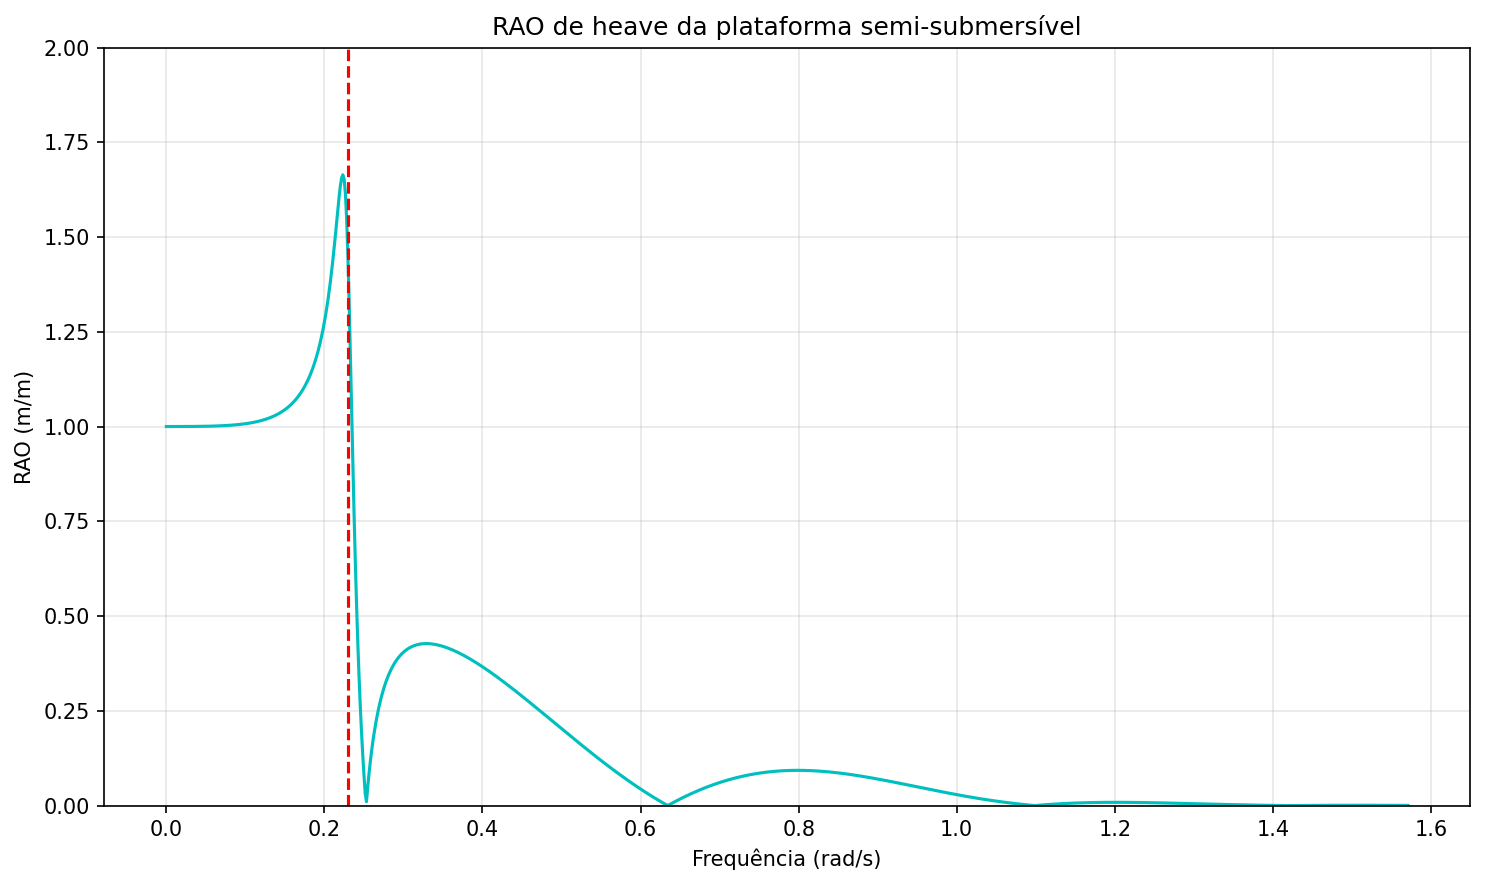


--- Indivíduos após otimização ---

Indivíduo com menor peso do casco:
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 82.15 m
  Largura dos pontoons (Bp): 8.19 m
  Altura dos pontoons (Hp): 15.89 m
  Largura das colunas (Bc): 6.85 m
  Altura das colunas (Hc): 29.23 m
  Calado (t): 36.49 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 25254.98 m³
  KB: 10.74 m
  BM: 10.19 m
  KM: 20.93 m
  Deslocamento em massa: 25886.35 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 55.12 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 7256.2 ton
  VCG estrutura casco: 12.55 m
  Peso riser: 967.5 ton
  Peso amarração: 725.6 ton

PESO PLATAFORMA:
  Peso total da plataforma: 25,881.4 ton
  KG plataforma: 42.53 m

PESO LASTRO:
  Deslocamento: 25886.4 ton
  Peso lastro: 5.0 ton
  VCG lastro: 7.95 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 8.6 m
  GM: -21.6 m

P

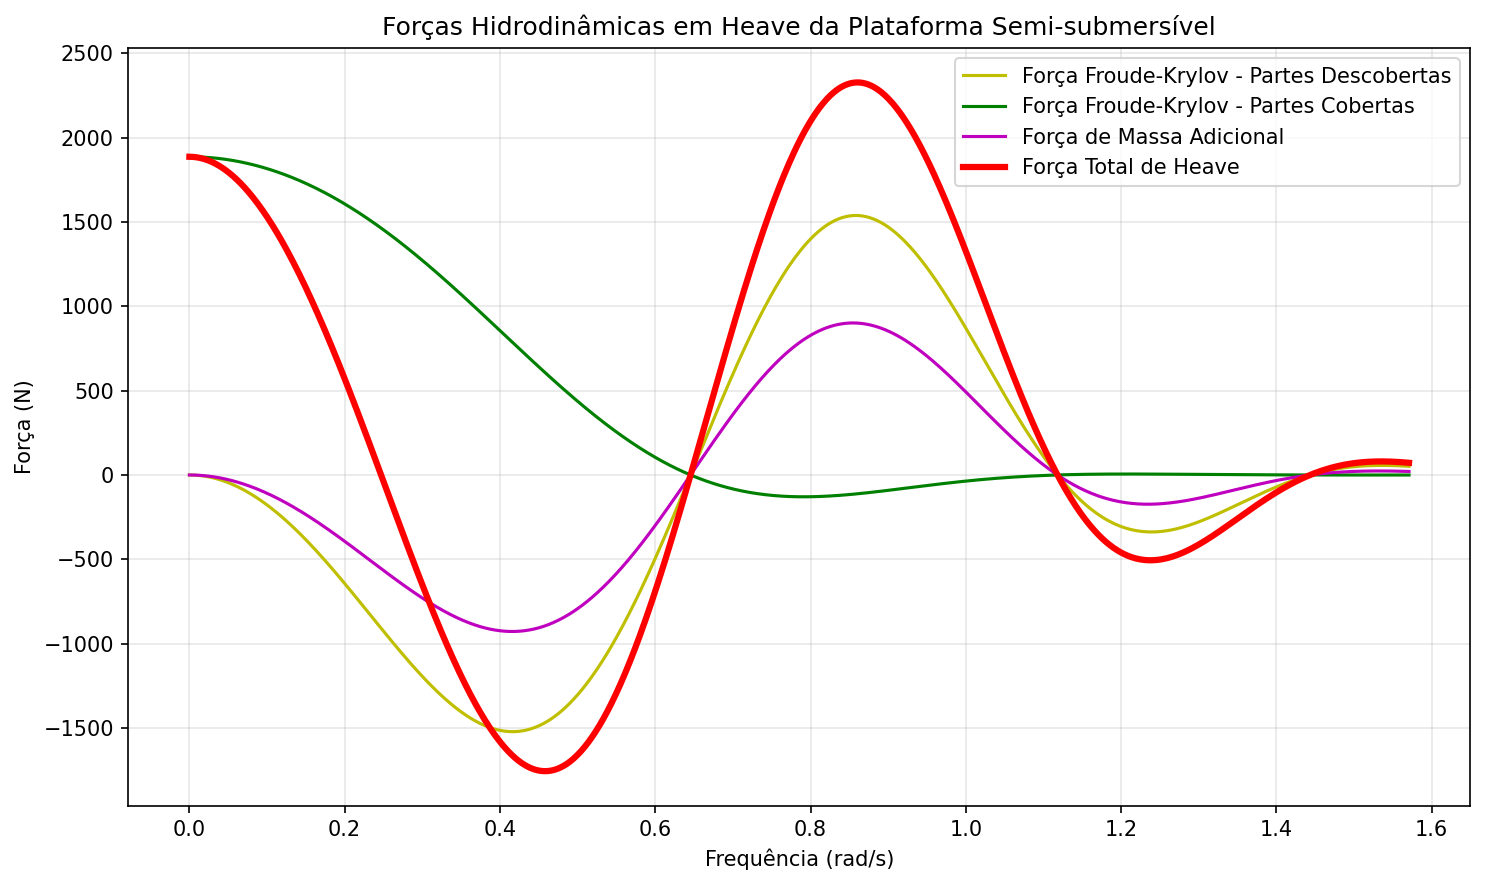

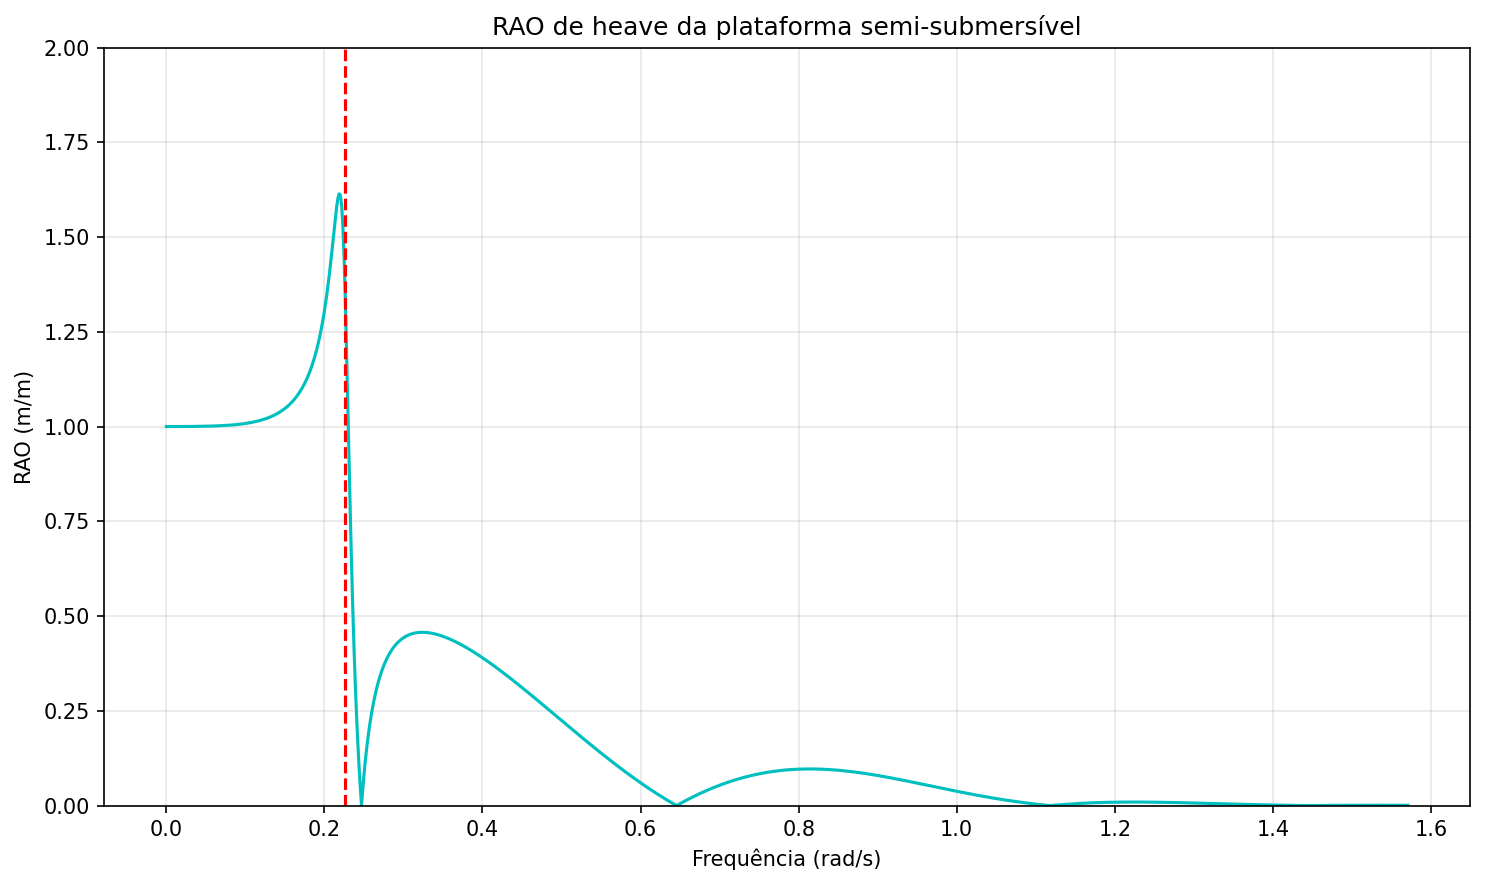

Indivíduo com maior Tn:
PARÂMETROS DE ENTRADA
  Comprimento dos pontoons (Lp): 88.53 m
  Largura dos pontoons (Bp): 7.93 m
  Altura dos pontoons (Hp): 16.93 m
  Largura das colunas (Bc): 6.18 m
  Altura das colunas (Hc): 39.45 m
  Calado (t): 38.26 m

PARÂMETROS HIDROSTÁTICOS:
  Volume deslocado: 27036.06 m³
  KB: 10.77 m
  BM: 9.21 m
  KM: 19.98 m
  Deslocamento em massa: 27711.96 t

TOPSIDE:
  Peso inicial do topside: 9960.0 ton
  Peso conves: 3486.0 ton
  Peso operacional: 3486.0 ton
  Peso total topside: 16932.0 ton
  VCG topside: 66.38 m
  Área do topside/deck: 9919.6 m²

ESTRUTURA DO CASCO:
  Peso estrutura casco: 8048.2 ton
  VCG estrutura casco: 14.17 m
  Peso riser: 999.2 ton
  Peso amarração: 749.4 ton

PESO PLATAFORMA:
  Peso total da plataforma: 26,728.8 ton
  KG plataforma: 50.32 m

PESO LASTRO:
  Deslocamento: 27712.0 ton
  Peso lastro: 983.1 ton
  VCG lastro: 8.47 m

ESTABILIDADE E SEGURANÇA:
  Airgap: 18.1 m
  GM: -30.3 m

PARÂMETROS HIDRODINÂMICOS:
  Massa adicional de

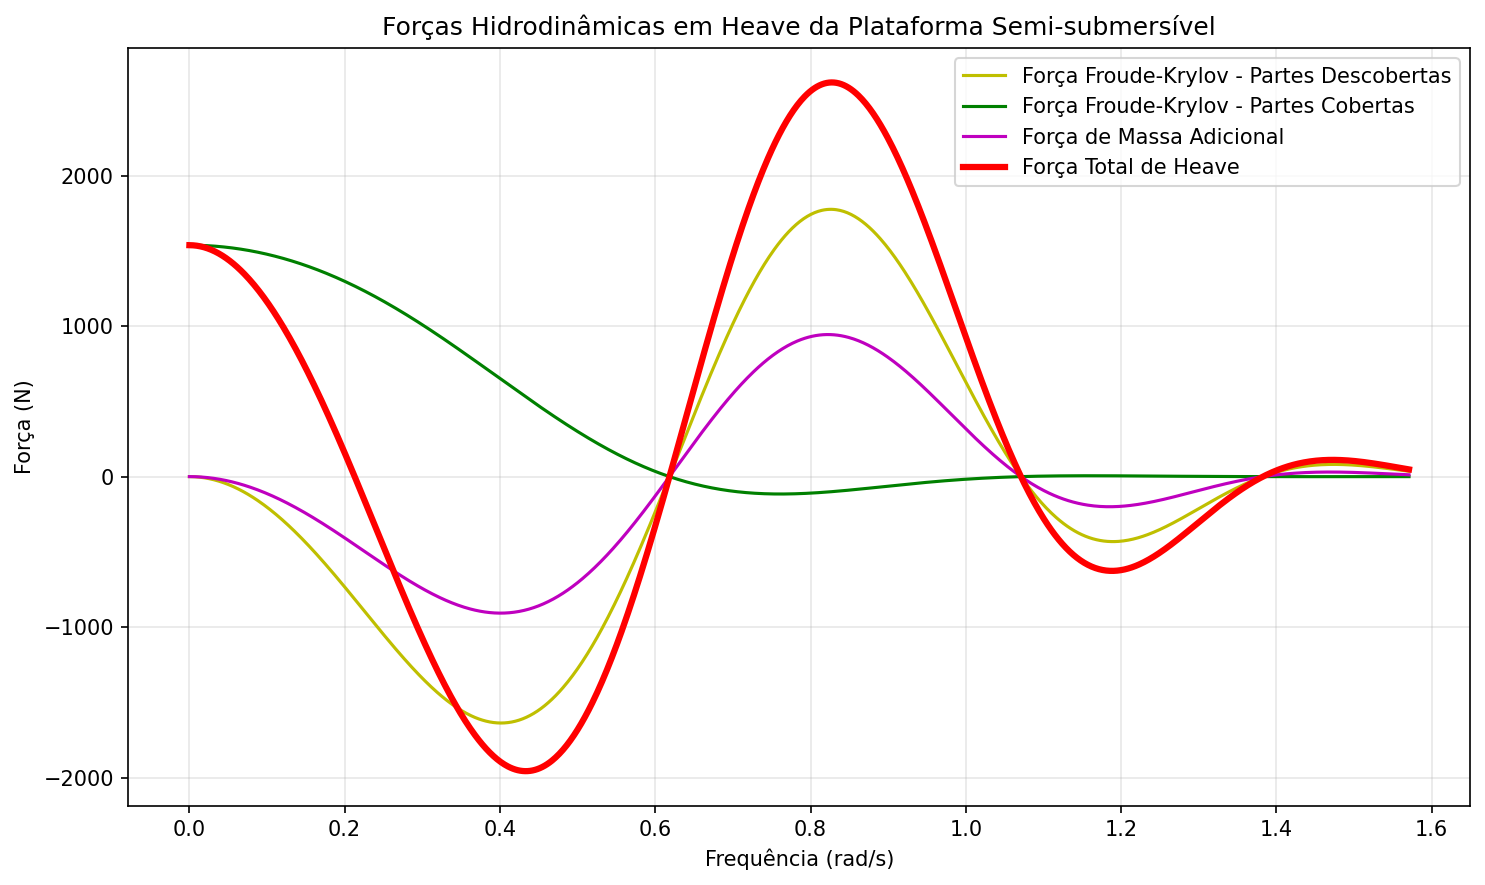

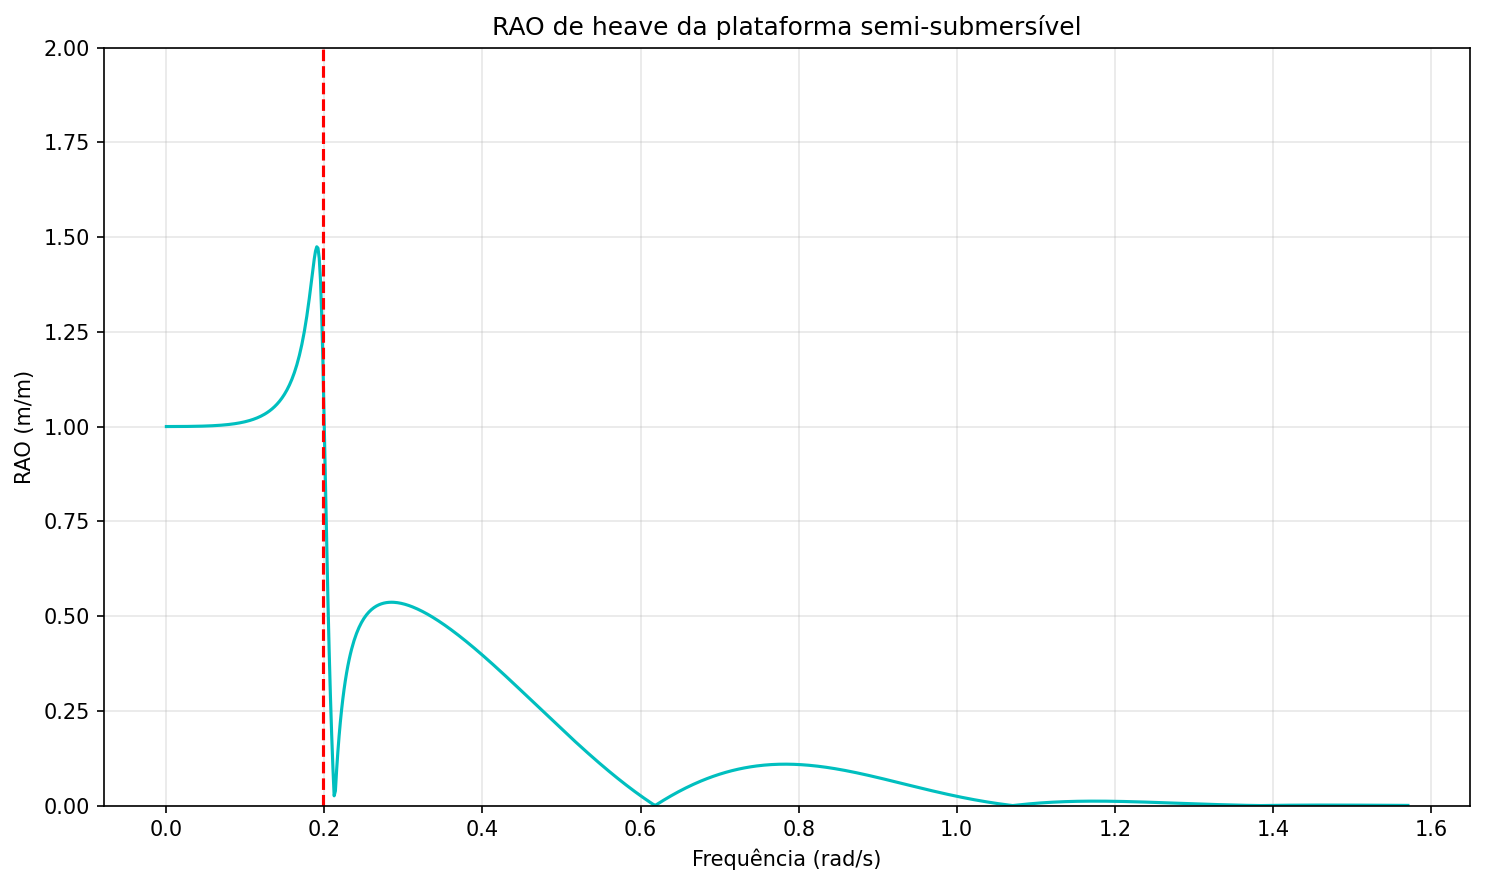

In [12]:
main()